Machine Learning-Based Financial Forecasting Using Multi-Asset Time Series Data for Intraday Trading

**INSTALL LIBRARIES**

In [1]:
!pip install tensorflow imbalanced-learn #library to handle imbalance
!pip install mplfinance # library to candlestick plotting library

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.7 MB/s eta 0:00:00


**MOUNT DRIVE**

In [2]:
from google.colab import drive #access data from drive
drive.mount('/content/drive')

Mounted at /content/drive


**Imports**

In [3]:
import tensorflow as tf
tf.keras.backend.clear_session() # Clears old models from memory
import gc # Clears old models from memory (important in loops)

import numpy as np #numerical operations
import pandas as pd #handles data
import matplotlib.pyplot as plt #plots
import seaborn as sns
import mplfinance as mpf #handles candestick chart

from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import StandardScaler #normalise data
from sklearn.utils.class_weight import compute_class_weight #handles class weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score #provides report

from sklearn.ensemble import RandomForestClassifier #rfm architecture
from imblearn.over_sampling import RandomOverSampler #duplicates minority classes to balance data

sns.set(style="whitegrid")

**Loss Function which is focal loss**

Reduce impact of easy predictions (like HOLD)

Focus learning on hard cases (BUY/SELL)

In [4]:
import tensorflow.keras.backend as K

def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = K.clip(y_pred, 1e-9, 1 - 1e-9)
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1 - y_pred, gamma)
        return K.sum(weight * cross_entropy, axis=1)
    return loss

**Parameters**

In [5]:
BASE_PATH = "/content/drive/MyDrive/FinanceProj1" #location of datasets
SEQ_LEN = 128 #each input is equal to 128 timesteps
EPOCHS = 80 # number of training iterations
BATCH_SIZE = 64
TRAIN_RATIO = 0.7 #percentage allocated for training
VAL_RATIO = 0.15  #percentage allocated for evaluation and testing
NUM_CLASSES = 3 #classes up, down or neutral
results_summary = [] #results of the pipeline

**Instruments**

In [6]:
INSTRUMENTS = {
    "IUFSUSUSD_5m": {"ask": f"{BASE_PATH}/IUFSUSUSD_5 Mins_Ask_2026.01.01_2026.04.13.csv",
                     "bid": f"{BASE_PATH}/IUFSUSUSD_5 Mins_Bid_2026.01.01_2026.04.13.csv"},#s&p 500 bid and ask data
    "BCHUSD_10m": {"ask": f"{BASE_PATH}/BCHUSD_10 Mins_Ask_2026.01.01_2026.04.13.csv",
                   "bid": f"{BASE_PATH}/BCHUSD_10 Mins_Bid_2026.01.01_2026.04.13.csv"}, #bitcoin/usd bid and ask data
    "XAUUSD_15m": {"ask": f"{BASE_PATH}/XAUUSD_15 Mins_Ask_2026.01.01_2026.04.13.csv",
                   "bid": f"{BASE_PATH}/XAUUSD_15 Mins_Bid_2026.01.01_2026.04.13.csv"}, #gold/usd bid and ask data
    "GBPUSD_30m": {"ask": f"{BASE_PATH}/GBPUSD_30 Mins_Ask_2026.01.01_2026.04.13.csv",
                   "bid": f"{BASE_PATH}/GBPUSD_30 Mins_Bid_2026.01.01_2026.04.13.csv"}, #gbp/usd bid and ask data
}

In [7]:
def merge_all_instruments():
    all_data = []

    for name, p in INSTRUMENTS.items():
        df = load_merge_bid_ask(p["ask"], p["bid"])
        df["instrument"] = name  # label the instrument
        all_data.append(df)

    merged_df = pd.concat(all_data, ignore_index=True)

    return merged_df

**Clean Data**

In [8]:
def clean_data(df): #function to clean data (delete duplicates)
    df = df.drop_duplicates()
    df = df.replace([np.inf, -np.inf], np.nan) #replace infinite values with nan
    df = df.dropna()
    return df.reset_index(drop=True) #reset index

**Load Data**

In [9]:
def load_merge_bid_ask(a,b): #function to load and merge csv files
    ask,bid = pd.read_csv(a),pd.read_csv(b) #load ask (a) and bid(b)
    for df in (ask,bid):
        df.columns = df.columns.str.lower().str.strip() #normalise column names
        df["datetime"] = pd.to_datetime(df["time (eet)"]) #convert timestamps

    ask.rename(columns=lambda x: f"Ask{x.capitalize()}" if x in ["open","high","low","close"] else x, inplace=True) #rename ask data OHLC
    bid.rename(columns=lambda x: f"Bid{x.capitalize()}" if x in ["open","high","low","close"] else x, inplace=True) #rename bidk data OHLC

    df = pd.merge(ask,bid,on="datetime").sort_values("datetime") #Merge both ask & bid

    for c in ["Open","High","Low","Close"]:
        df[f"Mid{c}"] = ((df[f"Ask{c}"] + df[f"Bid{c}"]) / 2).astype("float32") #create mid price and downgrade to float 32

    return clean_data(df) #reset data

**Feature Engineering**

Time features, Candle structure, Trend indicators, Momentum indicators, Volatility + regime


In [10]:
# FEATURES

def add_features(df):
    eps = 1e-9 #prevents division by zero


# TIME FEATURES

    df["hour"] = df["datetime"].dt.hour # 0-23 hours
    df["day_of_week"] = df["datetime"].dt.dayofweek # 0-6 days

    # cyclic encoding (VERY important)
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24) #convert days and time into circle representation
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)


#body, range, upper wick and lower wick is the candle structure and this code explains how we achieve it

    df["body"] = (df["MidClose"] - df["MidOpen"]).abs() #size of the candle
    df["range"] = df["MidHigh"] - df["MidLow"] #movement of the candle

    #Measures rejection
    df["upper_wick"] = df["MidHigh"] - df[["MidOpen","MidClose"]].max(axis=1) #selling pressure
    df["lower_wick"] = df[["MidOpen","MidClose"]].min(axis=1) - df["MidLow"]  #buying pressure

    df["body_ratio"] = df["body"]/(df["range"]+eps) #strength of the candle
    df["direction"] = np.sign(df["MidClose"]-df["MidOpen"]) #direction of candle +1(bullish) -1(bearish) 0(neutral)

#the trend indicators (EMA, MACD, alligator)
    df["EMA12"] = df["MidClose"].ewm(12).mean() #exponential moving average price trend detects trend direction in 12 and 26 period
    df["EMA26"] = df["MidClose"].ewm(26).mean()

    df["MACD"] = df["EMA12"] - df["EMA26"]
    df["Signal"] = df["MACD"].ewm(9).mean()

    df["Jaw"] = df["MidClose"].rolling(13).mean()
    df["Teeth"] = df["MidClose"].rolling(8).mean()
    df["Lips"] = df["MidClose"].rolling(5).mean()

#stochcastic indicators

    low14 = df["MidLow"].rolling(14).min()
    high14 = df["MidHigh"].rolling(14).max()
    df["stoch_k14"] = (df["MidClose"]-low14)/(high14-low14+eps)*100

    low21 = df["MidLow"].rolling(21).min()
    high21 = df["MidHigh"].rolling(21).max()
    df["stoch_k21"] = (df["MidClose"]-low21)/(high21-low21+eps)*100

    low28 = df["MidLow"].rolling(28).min()
    high28 = df["MidHigh"].rolling(28).max()
    df["stoch_k28"] = (df["MidClose"]-low28)/(high28-low28+eps)*100

    # VOLATILITY FEATURES

    df["returns"] = df["MidClose"].pct_change()

    df["volatility_10"] = df["returns"].rolling(10).std()
    df["volatility_20"] = df["returns"].rolling(20).std()
    df["volatility_50"] = df["returns"].rolling(50).std()

    # ATR (proxy)
    df["atr_14"] = (df["MidHigh"] - df["MidLow"]).rolling(14).mean()

    # MARKET REGIME

    df["trend_strength"] = df["EMA12"] - df["EMA26"]

    df["regime"] = 0
    df.loc[df["trend_strength"] > 0, "regime"] = 1   # bullish
    df.loc[df["trend_strength"] < 0, "regime"] = -1  # bearish

    return df.dropna().reset_index(drop=True)

In [11]:
def label_candles(df):
    df = df.copy()
    eps = 1e-9

    # ===============================
    # CANDLESTICK FEATURES (NOT LABELS)
    # ===============================
    body = abs(df["MidClose"] - df["MidOpen"])
    rng = df["MidHigh"] - df["MidLow"]

    upper = df["MidHigh"] - df[["MidOpen","MidClose"]].max(axis=1)
    lower = df[["MidOpen","MidClose"]].min(axis=1) - df["MidLow"]

    # Classic patterns as FEATURES
    df["is_hammer"] = ((lower / (rng + eps)) > 0.6).astype(int)
    df["is_shooting_star"] = ((upper / (rng + eps)) > 0.6).astype(int)
    df["is_doji"] = ((body / (rng + eps)) < 0.05).astype(int)

    # ===============================
    # TARGET LABEL (CLEAN + STABLE)
    # ===============================
    horizon = 6  # 🔥 increased from 6 → more meaningful moves

    df["future_return"] = df["MidClose"].shift(-horizon) / df["MidClose"] - 1

    # 🔥 FIXED threshold (NOT volatility-based)
    thr = 0.0015  # 0.15% → tune later if needed

    df["y"] = 0  # HOLD
    df.loc[df["future_return"] > thr, "y"] = 1   # BUY
    df.loc[df["future_return"] < -thr, "y"] = 2  # SELL

    return df.dropna().reset_index(drop=True)

**Features**

In [12]:
FEATURES = [
    "body","range","upper_wick","lower_wick","body_ratio",
    "direction","MACD","Signal","Jaw","Teeth","Lips",
    "stoch_k14","stoch_k21","stoch_k28",
    "volatility_10","volatility_20","volatility_50","atr_14",
    "trend_strength","regime",
    "hour_sin","hour_cos","dow_sin","dow_cos",

    # candlestick features
    "is_hammer","is_shooting_star","is_doji"
]

**SEQUENCE FUNCTION - converts data into time-series model**

Converts datasets into sliding windows

In [13]:
def create_sequences_from_array(data, labels):
    X, Y = [], [] #X= input sequence Y=target labels

    for i in range(SEQ_LEN, len(data) - 6): #ssix steps back
        X.append(data[i-SEQ_LEN:i])
        Y.append(labels[i+6]) #predict six steps ahead by looping

    return np.array(X), np.array(Y)

**Visuals**

In [14]:
def plot_confusion_matrix(y_true,y_pred):
    cm = confusion_matrix(y_true,y_pred)
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

def plot_equity_curve(preds, df):
    returns = df["MidClose"].pct_change().shift(-1).values
    strat=[]
    for i,p in enumerate(preds):
        if p==1: strat.append(returns[i+SEQ_LEN+6])
        elif p==2: strat.append(-returns[i+SEQ_LEN+6])
        else: strat.append(0)
    plt.plot(np.cumsum(strat)); plt.title("Equity Curve"); plt.show()

def plot_confidence(probs):
    plt.hist(np.max(probs,axis=1),bins=50)
    plt.title("Confidence"); plt.show()

def plot_training_history(history, title):
    # LOSS
    plt.plot(history.history['loss'], label='Train Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

    # ACCURACY
    if 'accuracy' in history.history:
        plt.plot(history.history['accuracy'], label='Train Accuracy')
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f"{title} Accuracy")
    plt.legend()
    plt.show()

def baseline_buy_hold(df, initial_balance=10000):
    returns = df["MidClose"].pct_change().fillna(0).values

    balance = initial_balance
    equity_curve = [balance]

    for r in returns:
        balance *= (1 + r)
        equity_curve.append(balance)

    return np.array(equity_curve)


def plot_model_vs_baseline(preds, df, title="Strategy vs Buy & Hold"):
    equity_model, _ = run_backtest(preds, df)
    equity_baseline = baseline_buy_hold(df)

    plt.figure(figsize=(10,5))
    plt.plot(equity_model, label="Model Strategy")
    plt.plot(equity_baseline[:len(equity_model)], label="Buy & Hold")
    plt.title(title)
    plt.legend()
    plt.show()

**Convolution Neural Network (CNN) Model**

In [15]:
def build_cnn(shape):
    return tf.keras.Sequential([
        layers.Input(shape),#defines input shape
        layers.Conv1D(64,3,activation="relu"), #applies 64 filters in 3 timesteps
        layers.MaxPooling1D(), #reduce size of data and keeps the strongest signal
        layers.Dropout(0.2), #drops 20% nuerons during traning to prevent overfitting
        layers.Conv1D(128,3,activation="relu"), # 128 filters applied more complex patterns
        layers.GlobalMaxPooling1D(), #converts sequence into single vector
        layers.Dropout(0.3), #drops 30% nuerons during traning to prevent overfitting
        layers.Dense(128,activation="relu"), #fully connected
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES,activation="softmax")
    ])

**Long Term  Short Memory (LSTM) Model**

In [16]:
def build_lstm(shape):
    return tf.keras.Sequential([
        layers.Input(shape),
        layers.LSTM(64,dropout=0.2,recurrent_dropout=0.2),
        layers.Dense(128,activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES,activation="softmax")
    ])

**Multi Layer Perceptron (MLP) Model**

In [17]:
def build_mlp(shape):
    return tf.keras.Sequential([
        layers.Input(shape),
        layers.Flatten(),
        layers.Dense(256,activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(128,activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES,activation="softmax")
    ])

**Hyperparameter Tuning**

Tries different learning rates

Tries different batch sizes

Trains a model for each combination

Evaluates performance using Sharpe ratio (financial metric, not just accuracy)

In [18]:
def tune_cnn(data): #function to tune CNN Hyperparameters
    print("\n===== HYPERPARAMETER TUNING =====")

    for name,(df,Xtr,Xv,Xte,Ytr,Yv,Yte,class_weight_dict) in data.items():#loop through all instruments
  #df =dataframe, Xtr, Xv, Xte = train/val/test inputs, Ytr,Yv,Yte = labels, class_weight_dict = inbalance handling
        for lr in [0.001, 0.0005]: #testing both slower and faster learning rate with different batch sizes
            for batch in [32, 64]:

                print(f"\n{name} | lr={lr}, batch={batch}")

                model = build_cnn((SEQ_LEN,len(FEATURES))) #build model
                model.compile(
                    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                    loss=focal_loss()
                )

                model.fit(
                    Xtr,
                    to_categorical(Ytr, NUM_CLASSES),
                    epochs=5,
                    batch_size=batch,
                    verbose=0
                ) #train model

                probs = model.predict(Xte) #probability
                preds = np.argmax(probs, axis=1) #prediction, 0-hold, 1-buy, 2-sell classes

                sharpe = calculate_sharpe(preds, df) #evaluate sharpe
                print(f"Sharpe: {sharpe:.3f}")

**Early Stopping**

This tells the model to stop training when the performance stops improving

In [19]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', #monitors validation loss
    patience=10, # waits 10 epochs before stopping
    restore_best_weights=True #keeps best performer
)

**Data Engineering and Preprocessing**
Loads each instrument

Builds features

Creates labels (BUY / HOLD / SELL)

Splits data (train/val/test)

Scales features properly (no leakage)

Converts into sequences (for deep learning)

Handles class imbalance

Stores everything for model training

In [20]:
def prepare_data():
    datasets = {}

    for name, p in INSTRUMENTS.items(): #to loop through the different instruments
        print(f"\nPreparing {name}...")

        df = load_merge_bid_ask(p["ask"], p["bid"]) #this load and merge data
        df = add_features(df) #add the predefined features
        df = label_candles(df) #add  the 3 labels


#splits data into test, train and validation
        n1 = int(len(df) * TRAIN_RATIO)
        n2 = int(len(df) * (TRAIN_RATIO + VAL_RATIO))

        df_train = df.iloc[:n1].reset_index(drop=True)
        df_val   = df.iloc[n1:n2].reset_index(drop=True)
        df_test  = df.iloc[n2:].reset_index(drop=True)

#fits scaler only on train data
        scaler = StandardScaler()
        scaler.fit(df_train[FEATURES])

# transform all splits
        train_scaled = scaler.transform(df_train[FEATURES])
        val_scaled   = scaler.transform(df_val[FEATURES])
        test_scaled  = scaler.transform(df_test[FEATURES])

        Y_train_raw = df_train["y"].values
        Y_val_raw   = df_val["y"].values
        Y_test_raw  = df_test["y"].values


  # Create sequences per split (converts flat data into sequences)

        Xtr, Ytr = create_sequences_from_array(train_scaled, Y_train_raw)
        Xv, Yv   = create_sequences_from_array(val_scaled, Y_val_raw)
        Xte, Yte = create_sequences_from_array(test_scaled, Y_test_raw)


#CLASS WEIGHTS

        classes = np.unique(Ytr) #handles class imbalance
        class_weights = compute_class_weight(
            class_weight='balanced',
            classes=classes,
            y=Ytr
        )

        class_weight_dict = dict(zip(classes, class_weights))

        # 🔥 boost minority classes
        for k in class_weight_dict:
            if k == 0:
                class_weight_dict[k] *= 1.0   # penalise neutral
            else:
                class_weight_dict[k] *= 2.0   # strongly boost trades

#store everyhting needed, dataframe, sequences and label
        datasets[name] = (
            df, Xtr, Xv, Xte,
            Ytr, Yv, Yte,
            class_weight_dict
        )
        print(f"\n{name} FULL label distribution:") #prints label distribution
        print(df["y"].value_counts(normalize=True))

        print(f"\n{name} TRAIN label distribution:")
        print(pd.Series(Ytr).value_counts(normalize=True))
    return datasets #all models can use the clean structure


**Ablation Study**
Shows the important features

In [21]:
def run_ablation(data):
    print("\n===== ABLATION STUDY =====") #defines functions and prints headers to information is easy to read

    feature_sets = {
        "ALL": FEATURES,

        "NO_CANDLE": [f for f in FEATURES if not f.startswith("is_")],

        "ONLY_TECH": [
            "MACD","Signal","Jaw","Teeth","Lips",
            "stoch_k14","stoch_k21","stoch_k28"
        ],

        "ONLY_PRICE": [
            "body","range","upper_wick","lower_wick","body_ratio","direction"
        ]
    }

    for name,(df,_,_,_,_,_,_,_) in data.items():
        print(f"\n{name}")

        for label, feats in feature_sets.items():
            scaler = StandardScaler()
            scaler.fit(df[feats])

            X_scaled = scaler.transform(df[feats])
            Y = df["y"].values

            X, Y = create_sequences_from_array(X_scaled, Y)

            split = int(len(X)*0.8)
            Xtr, Xte = X[:split], X[split:]
            Ytr, Yte = Y[:split], Y[split:]

            model = build_cnn((SEQ_LEN,len(feats)))
            model.compile(optimizer="adam",loss=focal_loss())

            model.fit(
                Xtr,
                to_categorical(Ytr, NUM_CLASSES),
                epochs=5,
                verbose=0
            )

            preds = np.argmax(model.predict(Xte),axis=1)

            acc = accuracy_score(Yte,preds)
            print(f"{label}: {acc:.4f}")

**Moving Average Strategy**

This implements a moving average crossover strategy:

In [22]:
def moving_average_strategy(df):
    short = df["MidClose"].rolling(10).mean() #computes a 10 period and looks at recent prices and reacts to changes
    long = df["MidClose"].rolling(50).mean() #computes a 50 period moving average

    preds = np.where(short > long, 1, 2)
    preds = preds[SEQ_LEN+6:]  # align

    return preds

**RUN_CNN**

In [23]:
def run_cnn(data):
    for name,(df,Xtr,Xv,Xte,Ytr,Yv,Yte,class_weight_dict) in data.items(): #unpack prepare function
        print(f"\nCNN → {name}")
        model=build_cnn((SEQ_LEN,len(FEATURES))) #build model

        #compile model
        model.compile(optimizer="adam",loss=focal_loss(),metrics=["accuracy"])

        #training
        history = model.fit(
            Xtr,
            to_categorical(Ytr, NUM_CLASSES),
            validation_data=(Xv, to_categorical(Yv, NUM_CLASSES)),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stop],
            class_weight=class_weight_dict,   # 🔥 ADD THIS
            verbose=0
        )
        plot_training_history(history, f"CNN - {name}")

        #predict
        probs=model.predict(Xte)
        preds = smart_predict(probs, threshold=0.25, df=df)
        errors = (preds != Yte)

        print("\nError Analysis:")
        print("Total Error Rate:", np.mean(errors))

        # align regime
        regimes = df.iloc[SEQ_LEN+6:SEQ_LEN+6+len(preds)]["regime"].values

        print("Error in Bullish:", np.mean(errors[regimes == 1]) if np.any(regimes==1) else 0)
        print("Error in Bearish:", np.mean(errors[regimes == -1]) if np.any(regimes==-1) else 0)
        print("Error in Neutral:", np.mean(errors[regimes == 0]) if np.any(regimes==0) else 0)

        plot_model_vs_baseline(preds, df, title=f"{name} - CNN vs Baseline")

        #backtest
        equity, trades = run_backtest(preds, df)
        print("\nTransaction Cost Sensitivity:")

        for cost in [0.0001, 0.0002, 0.0005]:
            equity_c, trades_c = run_backtest(preds, df, cost=cost)
            sharpe_c, _, _ = compute_metrics(equity_c, trades_c)
            print(f"Cost {cost}: Sharpe {sharpe_c:.3f}")

        sharpe, max_dd, win_rate = compute_metrics(equity, trades)

        #statistical testing
        from scipy.stats import ttest_1samp
        if len(trades) > 0:
            t_stat, p_val = ttest_1samp(trades, 0)
            if p_val < 0.05:
              print("Statistically significant strategy")
            else:
              print("Not statistically significant")

        results_summary.append({
            "Model": "CNN",
            "Instrument": name,
            "Sharpe": sharpe,
            "Max Drawdown": max_dd,
            "Win Rate": win_rate
        })

        # Moving average baseline
        ma_preds = moving_average_strategy(df)
        ma_equity, ma_trades = run_backtest(ma_preds, df)

        ma_sharpe, _, _ = compute_metrics(ma_equity, ma_trades)

        print(f"MA Strategy Sharpe: {ma_sharpe:.3f}")

        #buy/hold benchmark
        baseline_equity = baseline_buy_hold(df)
        baseline_returns = np.diff(baseline_equity) / baseline_equity[:-1]

        baseline_sharpe = 0
        if np.std(baseline_returns) > 0:
            baseline_sharpe = np.mean(baseline_returns) / np.std(baseline_returns) * np.sqrt(252*24)

        results_summary.append({
            "Model": "Buy & Hold",
            "Instrument": name,
            "Sharpe": baseline_sharpe,
            "Max Drawdown": np.nan,
            "Win Rate": np.nan
        })

        #Reports
        print(f"Max DD: {max_dd:.2%}")
        print(f"Win Rate: {win_rate:.2%}")
        print(f"Sharpe Ratio: {sharpe:.3f}")

        print(classification_report(Yte,preds))
        print("Total Errors:", np.sum(errors))
        print("False BUY:", np.sum((preds==1) & (Yte!=1)))
        print("False SELL:", np.sum((preds==2) & (Yte!=2)))
        plot_confusion_matrix(Yte,preds)
        plot_equity_curve(preds,df)
        plot_confidence(probs)
        errors = preds != Yte



**Long Short Term Memory (LSTM)**

Train an LSTM model

Evaluate predictions

Backtest trading performance

Compare vs Buy & Hold
Store results

In [24]:
def run_lstm(data):
    for name,(df,Xtr,Xv,Xte,Ytr,Yv,Yte,class_weight_dict) in data.items(): #unpack everything from prepare function(df, labels, sequences, imbalance handling)
        print(f"\nLSTM → {name}")
        model=build_lstm((SEQ_LEN,len(FEATURES))) #Model building
        model.compile(optimizer="adam",loss=focal_loss(),metrics=["accuracy"]) #compile model

        #training
        history = model.fit(
            Xtr,
            to_categorical(Ytr, NUM_CLASSES),
            validation_data=(Xv, to_categorical(Yv, NUM_CLASSES)),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stop],
            class_weight=class_weight_dict,   # 🔥 ADD THIS
            verbose=0
        )
        plot_training_history(history, f"LSTM - {name}")

        #predict
        probs=model.predict(Xte)
        preds = smart_predict(probs, threshold=0.25, df=df)
        errors = (preds != Yte)
        print("\nError Analysis:")
        print("Total Error Rate:", np.mean(errors))
        plot_model_vs_baseline(preds, df, title=f"{name} - LSTM vs Baseline")

        #backtest
        equity, trades = run_backtest(preds, df)

        #Metrics and store results
        sharpe, max_dd, win_rate = compute_metrics(equity, trades)
        results_summary.append({
            "Model": "LSTM",
            "Instrument": name,
            "Sharpe": sharpe,
            "Max Drawdown": max_dd,
            "Win Rate": win_rate
        })

        #buy and hold benchmark
        baseline_equity = baseline_buy_hold(df)
        baseline_returns = np.diff(baseline_equity) / baseline_equity[:-1]

        baseline_sharpe = 0
        if np.std(baseline_returns) > 0:
            baseline_sharpe = np.mean(baseline_returns) / np.std(baseline_returns) * np.sqrt(252*24)


        results_summary.append({
            "Model": "Buy & Hold",
            "Instrument": name,
            "Sharpe": baseline_sharpe,
            "Max Drawdown": np.nan,
            "Win Rate": np.nan
        })

        #Reports
        print(f"Max DD: {max_dd:.2%}")
        print(f"Win Rate: {win_rate:.2%}")
        print(f"Sharpe Ratio: {sharpe:.3f}")

        print(classification_report(Yte,preds))
        print("Total Errors:", np.sum(errors))
        print("False BUY:", np.sum((preds==1) & (Yte!=1)))
        print("False SELL:", np.sum((preds==2) & (Yte!=2)))
        plot_confusion_matrix(Yte,preds)
        plot_equity_curve(preds,df)
        plot_confidence(probs)

**Run MLP**

In [25]:
def run_mlp(data):
    for name,(df,Xtr,Xv,Xte,Ytr,Yv,Yte,class_weight_dict) in data.items():
        print(f"\nMLP → {name}")
        model=build_mlp((SEQ_LEN,len(FEATURES)))
        model.compile(optimizer="adam",loss=focal_loss(),metrics=["accuracy"])
        history = model.fit(
            Xtr,
            to_categorical(Ytr, NUM_CLASSES),
            validation_data=(Xv, to_categorical(Yv, NUM_CLASSES)),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stop],
            class_weight=class_weight_dict,   # 🔥 ADD THIS
            verbose=0
        )
        plot_training_history(history, f"MLP - {name}")

        probs=model.predict(Xte)
        preds = smart_predict(probs, threshold=0.4, df=df)
        errors = (preds != Yte)
        print("\nError Analysis:")
        print("Total Error Rate:", np.mean(errors))
        plot_model_vs_baseline(preds, df, title=f"{name} - MLP vs Baseline")

        equity, trades = run_backtest(preds, df)
        sharpe, max_dd, win_rate = compute_metrics(equity, trades)
        results_summary.append({
            "Model": "MLP",
            "Instrument": name,
            "Sharpe": sharpe,
            "Max Drawdown": max_dd,
            "Win Rate": win_rate
        })

        baseline_equity = baseline_buy_hold(df)
        baseline_returns = np.diff(baseline_equity) / baseline_equity[:-1]

        baseline_sharpe = 0
        if np.std(baseline_returns) > 0:
            baseline_sharpe = np.mean(baseline_returns) / np.std(baseline_returns) * np.sqrt(252*24)

        results_summary.append({
            "Model": "Buy & Hold",
            "Instrument": name,
            "Sharpe": baseline_sharpe,
            "Max Drawdown": np.nan,
            "Win Rate": np.nan
        })

        print(f"Max DD: {max_dd:.2%}")
        print(f"Win Rate: {win_rate:.2%}")
        print(f"Sharpe Ratio: {sharpe:.3f}")
        print("Total Errors:", np.sum(errors))
        print("False BUY:", np.sum((preds==1) & (Yte!=1)))
        print("False SELL:", np.sum((preds==2) & (Yte!=2)))

        print(classification_report(Yte,preds))
        plot_confusion_matrix(Yte,preds)
        plot_equity_curve(preds,df)
        plot_confidence(probs)

**Run Random Forest**

In [26]:
def run_rf(data):
    for name,(df,Xtr,Xv,Xte,Ytr,Yv,Yte,_) in data.items():
        print(f"\nRF → {name}")

        rf = RandomForestClassifier(n_estimators=200)

        rf.fit(
            Xtr.reshape(Xtr.shape[0], -1),
            Ytr
        )
        importances = rf.feature_importances_

        print("\nFeature Importance:")
        for f, imp in zip(FEATURES, importances[:len(FEATURES)]):
            print(f"{f}: {imp:.4f}")

        preds = rf.predict(
            Xte.reshape(Xte.shape[0], -1)
        )

        print(classification_report(Yte, preds))
        plot_confusion_matrix(Yte, preds)

**Run Ensemble**

In [27]:
# ===============================
# RUN ENSEMBLE
# ===============================
def run_ensemble(data):
    for name,(df,Xtr,Xv,Xte,Ytr,Yv,Yte,class_weight_dict) in data.items():
        print(f"\nENSEMBLE → {name}")

        models=[build_cnn((SEQ_LEN,len(FEATURES))),
                build_lstm((SEQ_LEN,len(FEATURES))),
                build_mlp((SEQ_LEN,len(FEATURES)))]

        preds_sum=np.zeros((len(Yte),NUM_CLASSES))

        for model in models:
            model.compile(optimizer="adam",loss=focal_loss())
            history = model.fit(
            Xtr,
            to_categorical(Ytr, NUM_CLASSES),
            validation_data=(Xv, to_categorical(Yv, NUM_CLASSES)),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stop],
            class_weight=class_weight_dict,   # 🔥 ADD THIS
            verbose=0
        )
            preds_sum+=model.predict(Xte)

        probs=preds_sum/len(models)
        preds = smart_predict(probs, threshold=0.25, df=df)
        plot_model_vs_baseline(preds, df, title=f"{name} - ENSEMBLE vs Baseline")
        errors = (preds != Yte)
        print("\nError Analysis:")
        print("Total Error Rate:", np.mean(errors))

        equity, trades = run_backtest(preds, df)
        sharpe, max_dd, win_rate = compute_metrics(equity, trades)
        results_summary.append({
            "Model": "ENSEMBLE",
            "Instrument": name,
            "Sharpe": sharpe,
            "Max Drawdown": max_dd,
            "Win Rate": win_rate
        })

        baseline_equity = baseline_buy_hold(df)
        baseline_returns = np.diff(baseline_equity) / baseline_equity[:-1]

        baseline_sharpe = 0
        if np.std(baseline_returns) > 0:
            baseline_sharpe = np.mean(baseline_returns) / np.std(baseline_returns) * np.sqrt(252*24)

        results_summary.append({
            "Model": "Buy & Hold",
            "Instrument": name,
            "Sharpe": baseline_sharpe,
            "Max Drawdown": np.nan,
            "Win Rate": np.nan
        })

        #Reports
        print(f"Max DD: {max_dd:.2%}")
        print(f"Win Rate: {win_rate:.2%}")
        print(f"Sharpe Ratio: {sharpe:.3f}")

        print(classification_report(Yte,preds))
        print("Total Errors:", np.sum(errors))
        print("False BUY:", np.sum((preds==1) & (Yte!=1)))
        print("False SELL:", np.sum((preds==2) & (Yte!=2)))

        plot_confusion_matrix(Yte,preds)
        plot_equity_curve(preds,df)
        plot_confidence(probs)
        plot_training_history(history, f"ENSEMBLE - {name}")

**Backtest**

In [28]:
def run_backtest(preds, df, initial_balance=10000, cost=0.0002): #prediction, df, initial balance, cost
    returns = df["MidClose"].pct_change().shift(-1).values #compute price change, and aligns future return prediction

    balance = initial_balance #initial portfolio
    equity_curve = [balance]
    trades = []

    for i, p in enumerate(preds): #loop through predictions
        idx = i + SEQ_LEN + 6 #alighns prediciton with actual price

        if idx >= len(returns): #skip if you do not have future data
            continue

        min_move = 0.001  # 0.1% minimum move filter

        if p == 1 and abs(returns[idx]) > min_move: #buy if price goes up
            r = returns[idx] - cost
        elif p == 2 and abs(returns[idx]) > min_move: #sell if price goes down
            r = -returns[idx] - cost
        else: #hold / no trade
            r = 0

        balance *= (1 + r)
        equity_curve.append(balance)

        if p != 0: #update portfolio
            trades.append(r)

    return np.array(equity_curve), np.array(trades) #return results

**Metrics**

Sharpe Ratio

Max Drwadown

Win Rate


In [29]:
def compute_metrics(equity, trades): #use equity and trades to calculate metrics
    returns = np.diff(equity) / equity[:-1] #converts equity cureve into percentage

    sharpe = 0
    if np.std(returns) > 0:
        sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252*24)

    # max drawdown
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / peak
    max_dd = dd.min()

    win_rate = 0
    if len(trades) > 0:
        win_rate = np.mean(trades > 0)

    return sharpe, max_dd, win_rate

**Intelligence Function**
decision intelligence on top of the model
Smart Filter

In [30]:
def smart_predict(probs, threshold=0.6, df=None):
    preds = []

    for i, p in enumerate(probs):
        cls = np.argmax(p)

        # 🔥 REGIME FILTER
        if df is not None:
            regime = df.iloc[i + SEQ_LEN]["regime"]

            if regime == 1 and cls == 2:
                cls = 0  # block SELL in uptrend
            elif regime == -1 and cls == 1:
                cls = 0  # block BUY in downtrend

        # confidence filter
        if cls != 0 and p[cls] < threshold:
            preds.append(0)
        else:
            preds.append(cls)

    return np.array(preds)

**Walk-Forward**

In [31]:
def walk_forward_proper(model_builder, df, name, step=2000):
    print(f"\nWALK-FORWARD → {name}")

    scaler = StandardScaler()
    all_sharpes = []

    for start in range(0, len(df) - step*2, step*2): #walkforward loop

        train_df = df.iloc[start:start+step]
        test_df  = df.iloc[start+step:start+step*2]

        if len(test_df) < step:
            continue

        # FIT ONLY ON TRAIN
        scaler.fit(train_df[FEATURES])

        X_train_raw = scaler.transform(train_df[FEATURES])
        X_test_raw  = scaler.transform(test_df[FEATURES])

        Y_train = train_df["y"].values
        Y_test  = test_df["y"].values

        # CREATE SEQUENCES
        Xtr, Ytr = create_sequences_from_array(X_train_raw, Y_train)
        Xte, Yte = create_sequences_from_array(X_test_raw, Y_test)

        if len(Xte) == 0:
            continue

        # TRAIN MODEL
        model = model_builder((SEQ_LEN, len(FEATURES)))
        model.compile(optimizer="adam", loss=focal_loss())

        model.fit(
            Xtr,
            to_categorical(Ytr, NUM_CLASSES),
            epochs=5,
            batch_size=64,
            verbose=0
        )

        probs = model.predict(Xte)
        preds = smart_predict(probs, threshold=0.5)

        equity, trades = run_backtest(preds, test_df)
        sharpe, _, _ = compute_metrics(equity, trades)

        all_sharpes.append(sharpe)

    # OUTSIDE LOOP skip empty cases
    if len(all_sharpes) == 0:
        print("No valid walk-forward windows")
        return

    print(f"\nWalk-forward results for {name}")
    print("Mean Sharpe:", np.mean(all_sharpes))
    print("Std Sharpe:", np.std(all_sharpes))
    print("Min Sharpe:", np.min(all_sharpes))
    print("Max Sharpe:", np.max(all_sharpes))

**Sharpe Ratio**

In [32]:
def calculate_sharpe(preds, df):
    returns = df["MidClose"].pct_change().shift(-1).values

    strat = []
    for i, p in enumerate(preds):
        idx = i + SEQ_LEN + 6  # 🔥 FIXED ALIGNMENT

        if idx >= len(returns):
            continue

        if p == 1 and abs(returns[idx]) > 0.0002:
            strat.append(returns[idx])
        elif p == 2 and abs(returns[idx]) > 0.0002:
            strat.append(-returns[idx])
        else:
            strat.append(0)

    strat = np.array(strat)

    if np.std(strat) == 0:
        return 0

    return np.mean(strat) / np.std(strat) * np.sqrt(252*24)

**Results**

In [33]:
def show_results_table():
    df_results = pd.DataFrame(results_summary)

    print("\n===== FINAL RESULTS TABLE =====")
    print(df_results.sort_values(by="Sharpe", ascending=False))

    pivot = df_results.pivot_table(
        index="Instrument",
        columns="Model",
        values="Sharpe"
    )

    print("\n===== SHARPE RATIO COMPARISON =====")
    print(pivot)

    return df_results

In [34]:
data = prepare_data()


Preparing IUFSUSUSD_5m...

IUFSUSUSD_5m FULL label distribution:
y
0    0.664933
2    0.177868
1    0.157199
Name: proportion, dtype: float64

IUFSUSUSD_5m TRAIN label distribution:
0    0.702312
2    0.157102
1    0.140586
Name: proportion, dtype: float64

Preparing BCHUSD_10m...

BCHUSD_10m FULL label distribution:
y
2    0.377816
1    0.352550
0    0.269634
Name: proportion, dtype: float64

BCHUSD_10m TRAIN label distribution:
2    0.396075
1    0.364456
0    0.239469
Name: proportion, dtype: float64

Preparing XAUUSD_15m...

XAUUSD_15m FULL label distribution:
y
1    0.353198
0    0.340718
2    0.306084
Name: proportion, dtype: float64

XAUUSD_15m TRAIN label distribution:
0    0.362738
1    0.356306
2    0.280956
Name: proportion, dtype: float64

Preparing GBPUSD_30m...

GBPUSD_30m FULL label distribution:
y
0    0.704768
1    0.150133
2    0.145099
Name: proportion, dtype: float64

GBPUSD_30m TRAIN label distribution:
0    0.724092
2    0.138627
1    0.137281
Name: proportion, d


CNN → IUFSUSUSD_5m


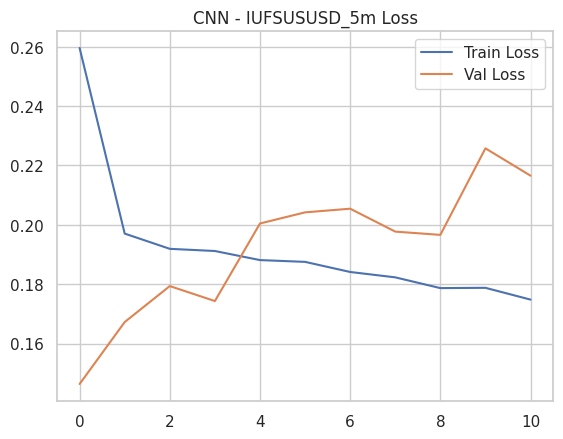

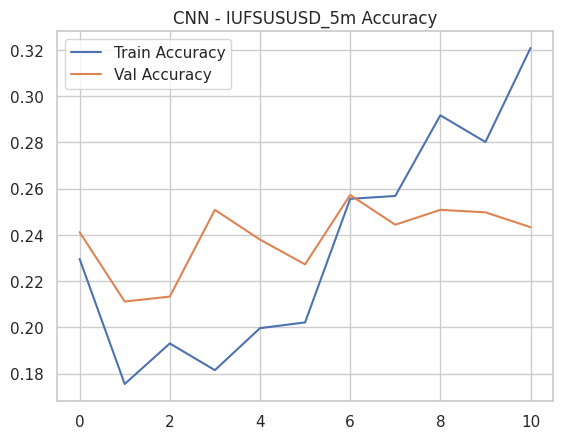

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step

Error Analysis:
Total Error Rate: 0.5744908896034298
Error in Bullish: 0.4215500945179584
Error in Bearish: 0.7747524752475248
Error in Neutral: 0


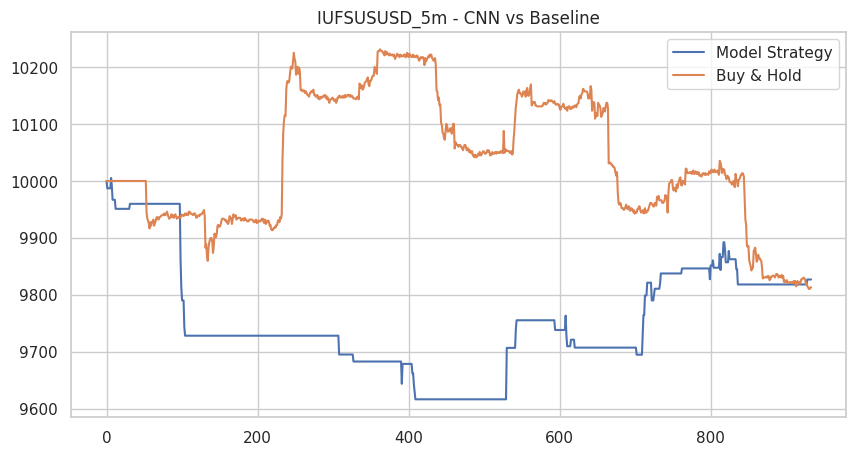


Transaction Cost Sensitivity:
Cost 0.0001: Sharpe -1.380
Cost 0.0002: Sharpe -2.004
Cost 0.0005: Sharpe -3.833
Not statistically significant
MA Strategy Sharpe: -1.380
Max DD: -3.89%
Win Rate: 6.02%
Sharpe Ratio: -2.004
              precision    recall  f1-score   support

           0       0.61      0.55      0.58       590
           1       0.42      0.03      0.05       173
           2       0.18      0.40      0.24       170

    accuracy                           0.43       933
   macro avg       0.40      0.33      0.29       933
weighted avg       0.49      0.43      0.42       933

Total Errors: 536
False BUY: 7
False SELL: 319


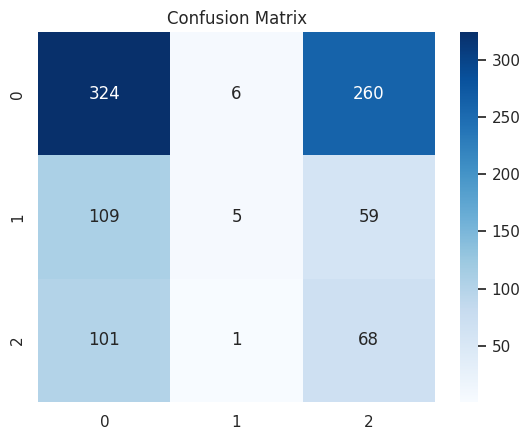

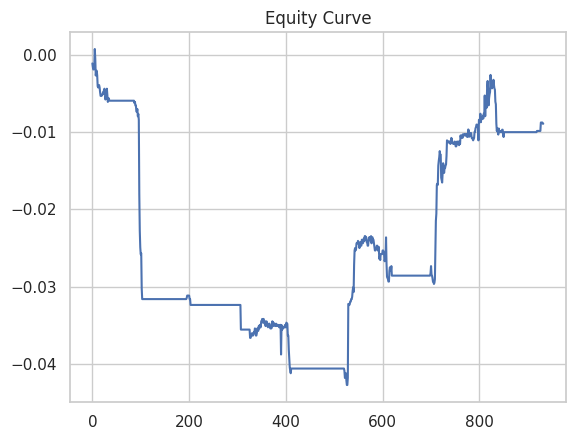

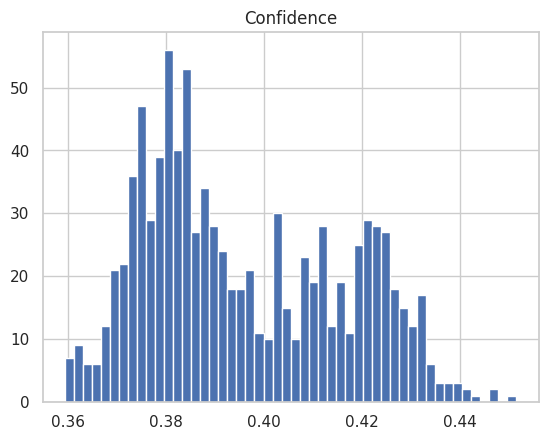


CNN → BCHUSD_10m


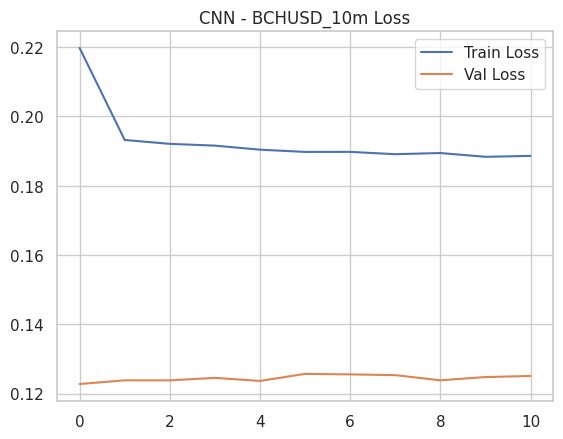

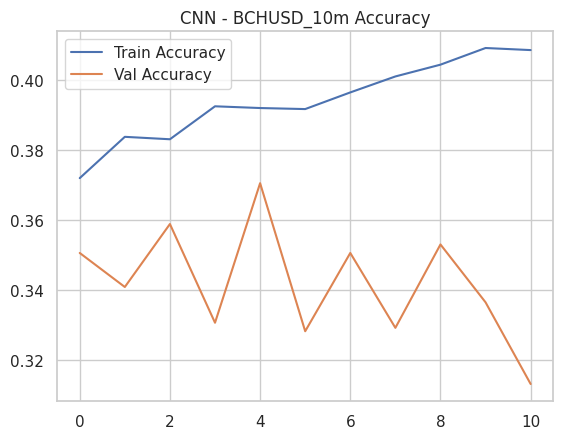

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Error Analysis:
Total Error Rate: 0.6456003889158969
Error in Bullish: 0.655893536121673
Error in Bearish: 0.6348258706467662
Error in Neutral: 0


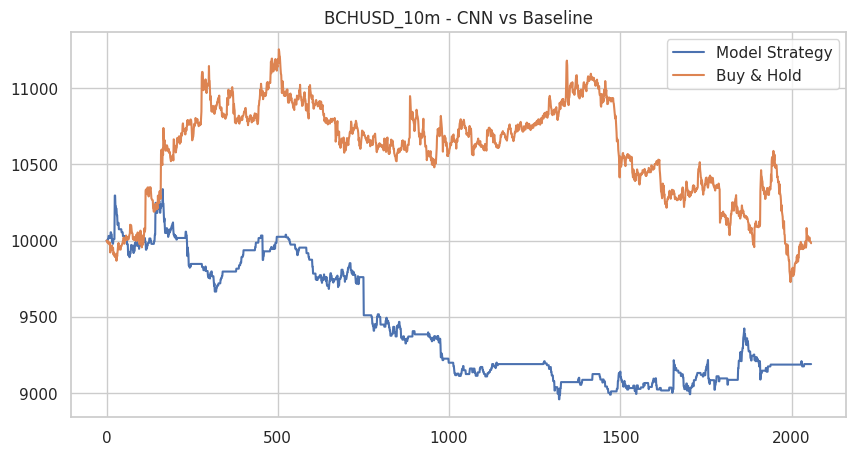


Transaction Cost Sensitivity:
Cost 0.0001: Sharpe -0.570
Cost 0.0002: Sharpe -1.608
Cost 0.0005: Sharpe -4.701
Not statistically significant
MA Strategy Sharpe: -3.174
Max DD: -13.33%
Win Rate: 29.56%
Sharpe Ratio: -1.608
              precision    recall  f1-score   support

           0       0.37      0.57      0.45       754
           1       0.31      0.18      0.23       607
           2       0.35      0.27      0.31       696

    accuracy                           0.35      2057
   macro avg       0.34      0.34      0.33      2057
weighted avg       0.35      0.35      0.34      2057

Total Errors: 1328
False BUY: 247
False SELL: 347


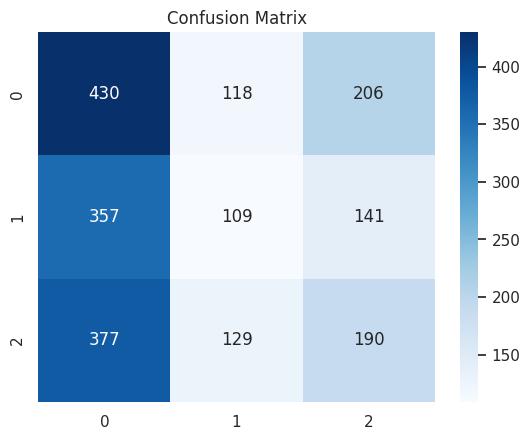

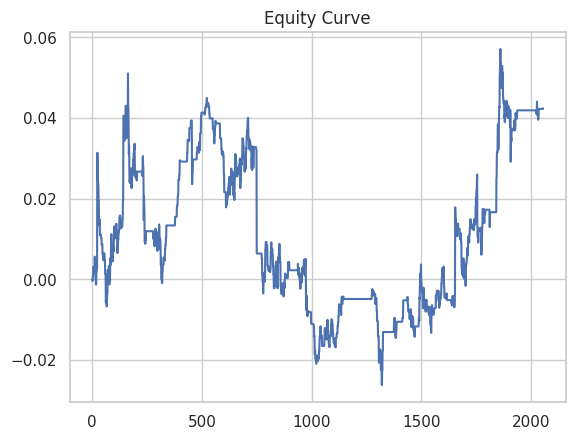

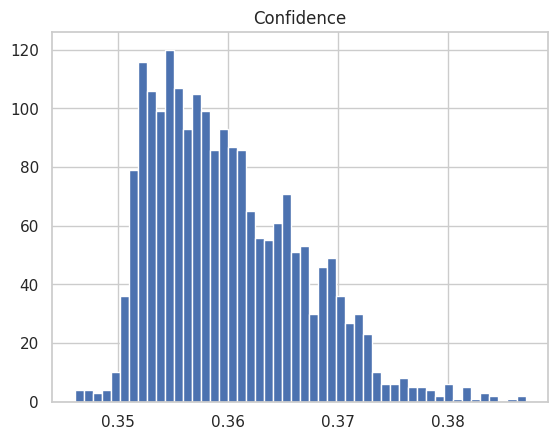


CNN → XAUUSD_15m


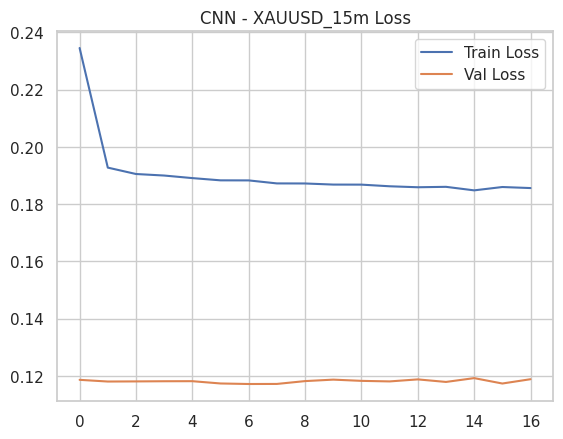

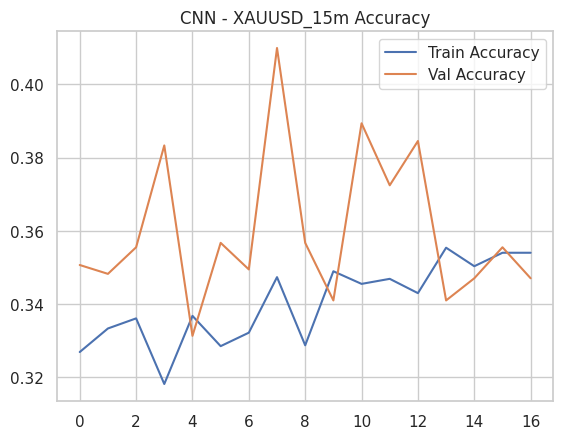

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step

Error Analysis:
Total Error Rate: 0.6545893719806763
Error in Bullish: 0.6836734693877551
Error in Bearish: 0.6124260355029586
Error in Neutral: 0


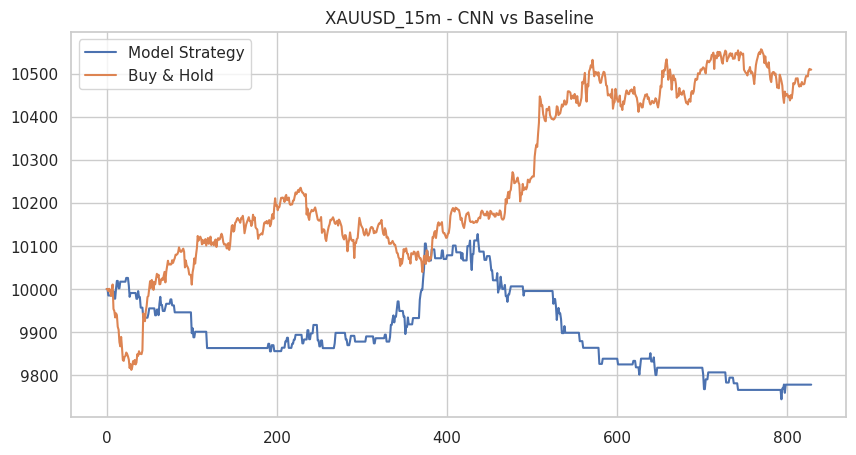


Transaction Cost Sensitivity:
Cost 0.0001: Sharpe -0.544
Cost 0.0002: Sharpe -2.298
Cost 0.0005: Sharpe -7.441
Not statistically significant
MA Strategy Sharpe: -2.329
Max DD: -3.79%
Win Rate: 17.28%
Sharpe Ratio: -2.298
              precision    recall  f1-score   support

           0       0.34      0.40      0.37       270
           1       0.34      0.54      0.42       299
           2       0.37      0.07      0.12       259

    accuracy                           0.35       828
   macro avg       0.35      0.33      0.30       828
weighted avg       0.35      0.35      0.31       828

Total Errors: 542
False BUY: 304
False SELL: 32


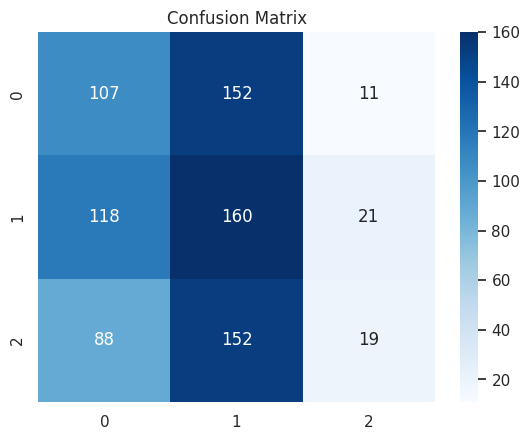

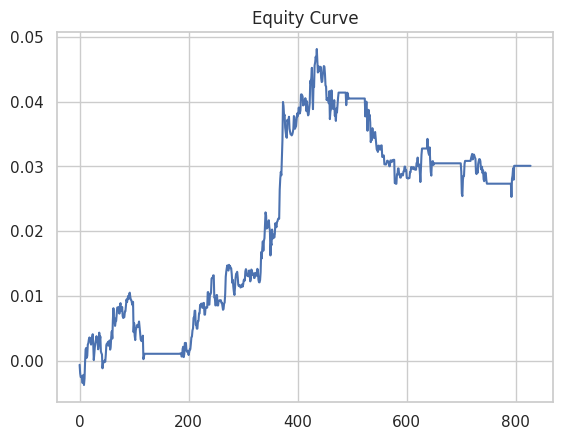

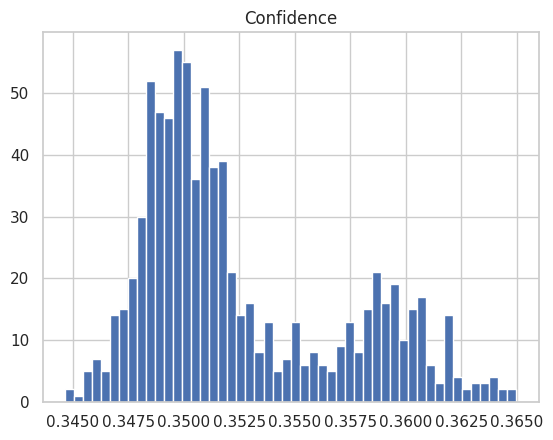


CNN → GBPUSD_30m


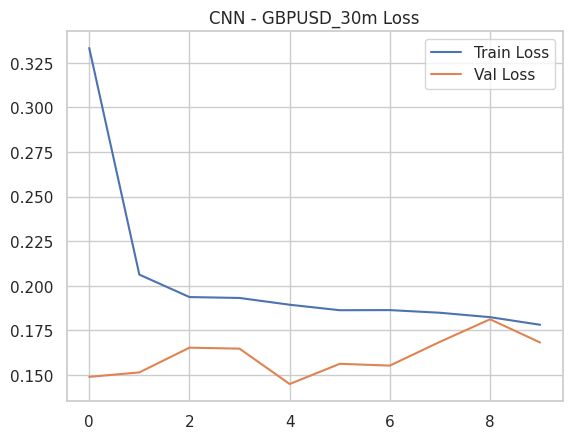

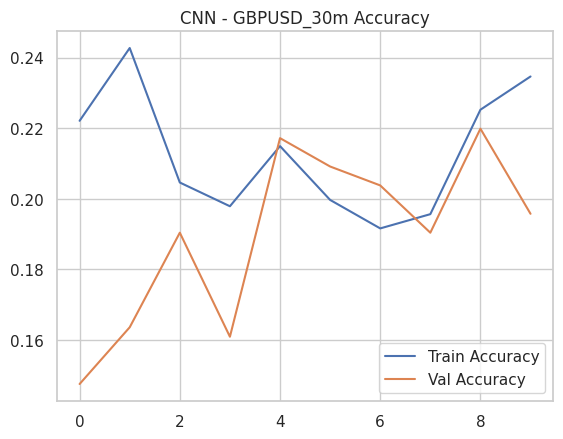

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step

Error Analysis:
Total Error Rate: 0.3699731903485255
Error in Bullish: 0.46511627906976744
Error in Bearish: 0.34146341463414637
Error in Neutral: 0


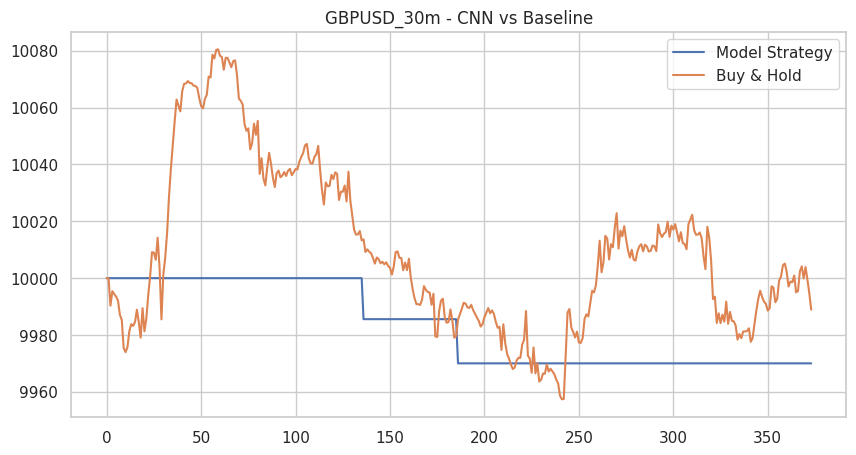


Transaction Cost Sensitivity:
Cost 0.0001: Sharpe -5.705
Cost 0.0002: Sharpe -5.706
Cost 0.0005: Sharpe -5.707
Not statistically significant
MA Strategy Sharpe: -2.405
Max DD: -0.30%
Win Rate: 0.00%
Sharpe Ratio: -5.706
              precision    recall  f1-score   support

           0       0.73      0.85      0.78       263
           1       0.23      0.16      0.19        68
           2       0.00      0.00      0.00        42

    accuracy                           0.63       373
   macro avg       0.32      0.34      0.32       373
weighted avg       0.55      0.63      0.59       373

Total Errors: 138
False BUY: 37
False SELL: 17


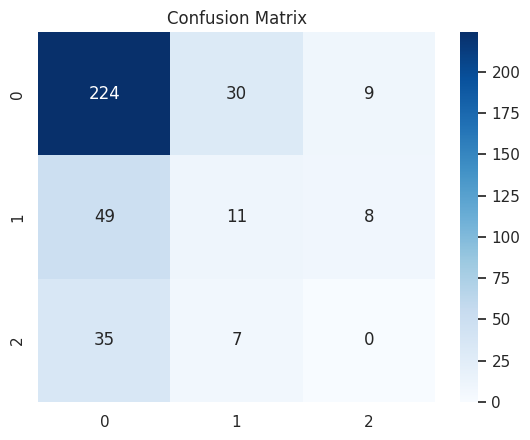

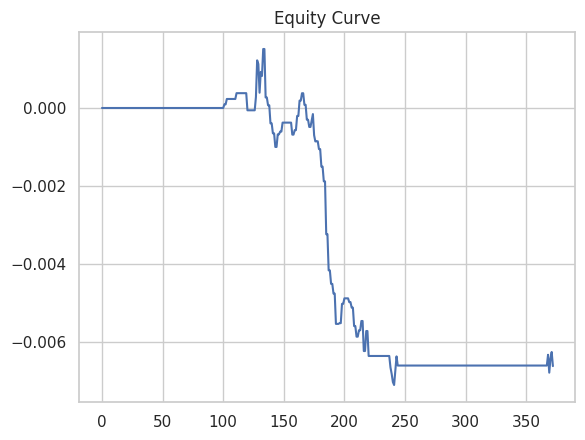

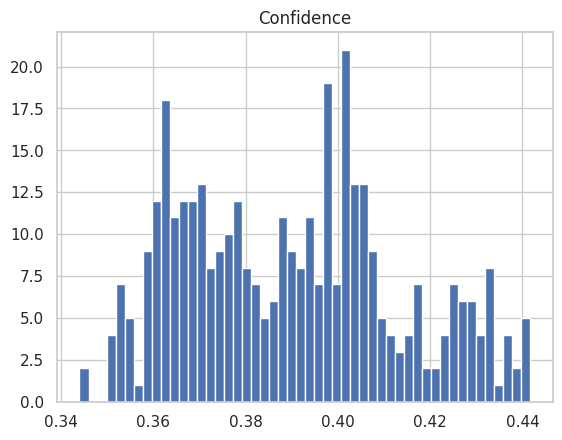

In [35]:
run_cnn(data)



LSTM → IUFSUSUSD_5m


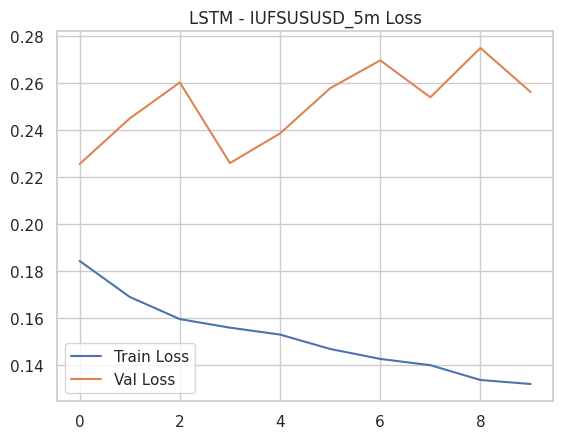

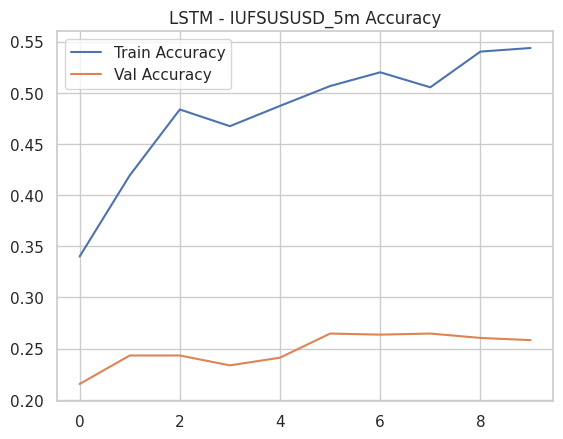

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step

Error Analysis:
Total Error Rate: 0.587352625937835


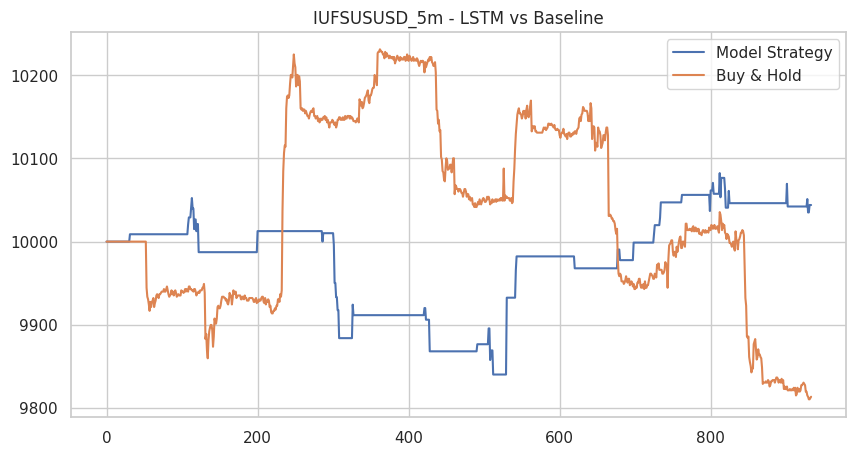

Max DD: -2.11%
Win Rate: 6.50%
Sharpe Ratio: 0.642
              precision    recall  f1-score   support

           0       0.64      0.48      0.55       590
           1       0.26      0.45      0.33       173
           2       0.13      0.16      0.15       170

    accuracy                           0.41       933
   macro avg       0.35      0.36      0.34       933
weighted avg       0.48      0.41      0.43       933

Total Errors: 548
False BUY: 214
False SELL: 174


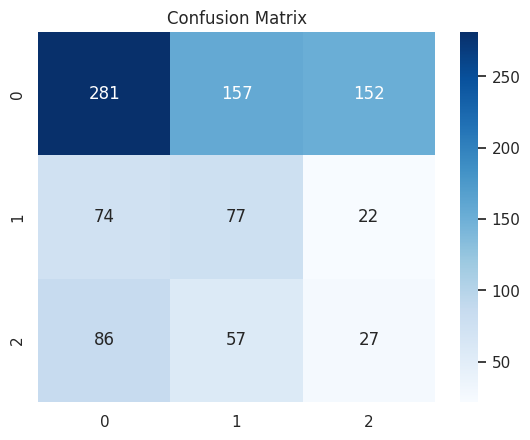

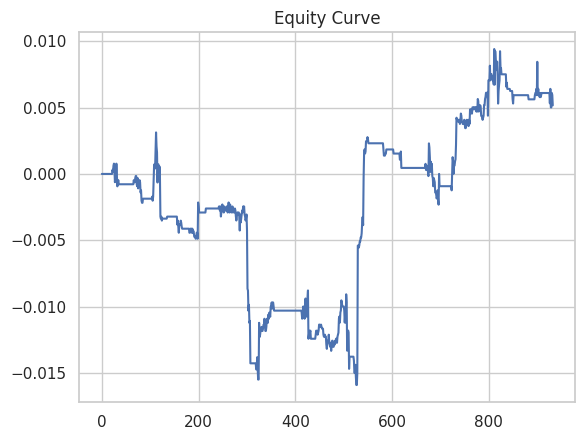

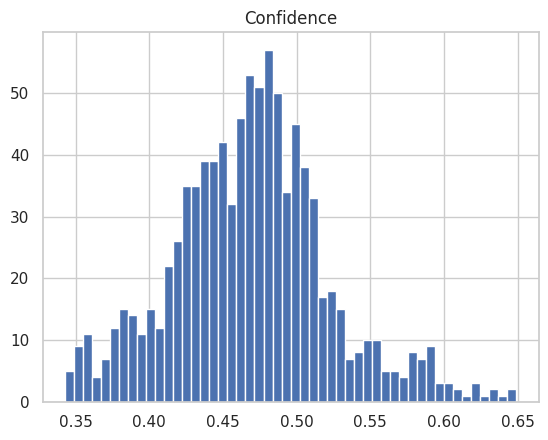


LSTM → BCHUSD_10m


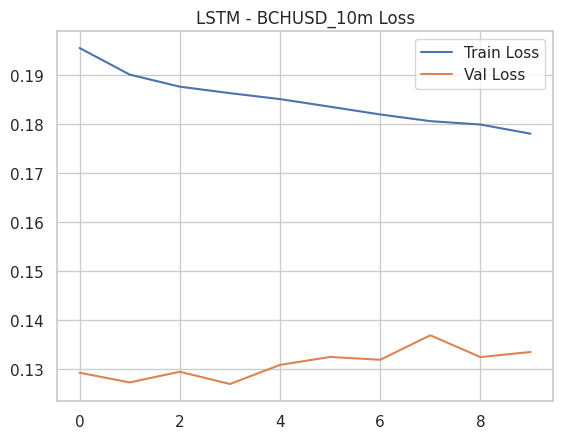

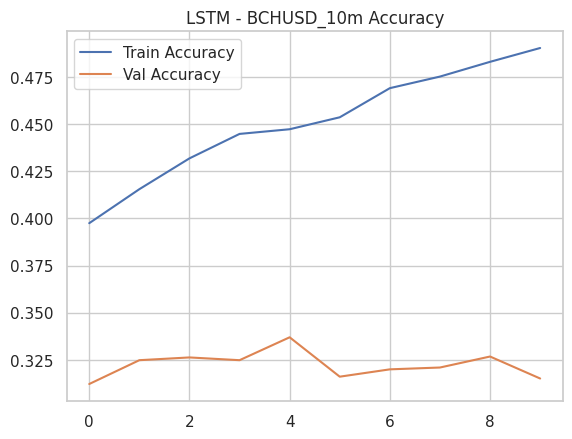

65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step

Error Analysis:
Total Error Rate: 0.648031113271755


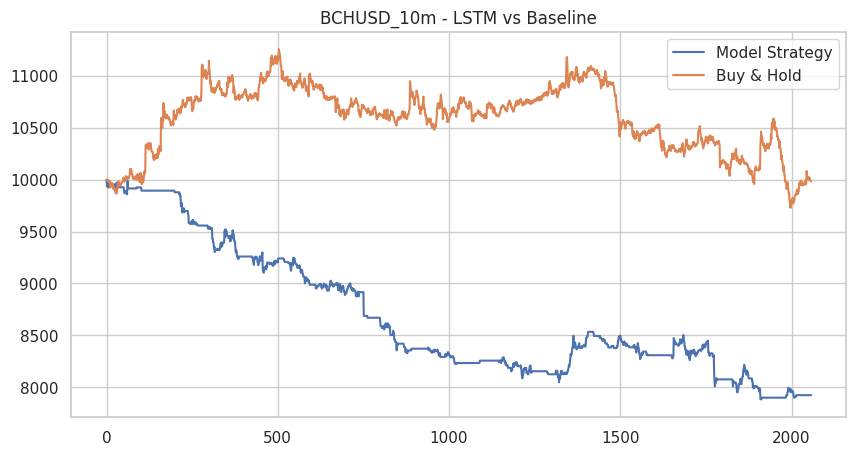

Max DD: -21.16%
Win Rate: 29.49%
Sharpe Ratio: -4.246
              precision    recall  f1-score   support

           0       0.37      0.49      0.42       754
           1       0.36      0.15      0.22       607
           2       0.33      0.38      0.35       696

    accuracy                           0.35      2057
   macro avg       0.35      0.34      0.33      2057
weighted avg       0.35      0.35      0.34      2057

Total Errors: 1333
False BUY: 162
False SELL: 540


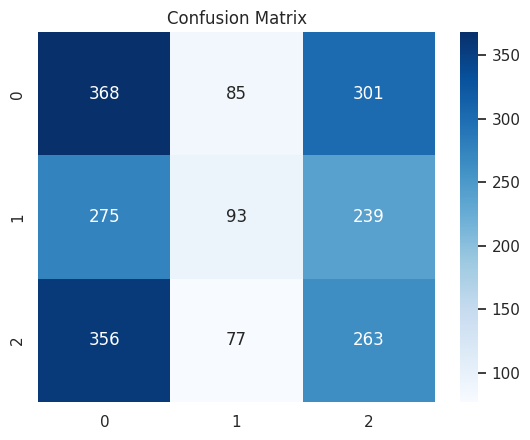

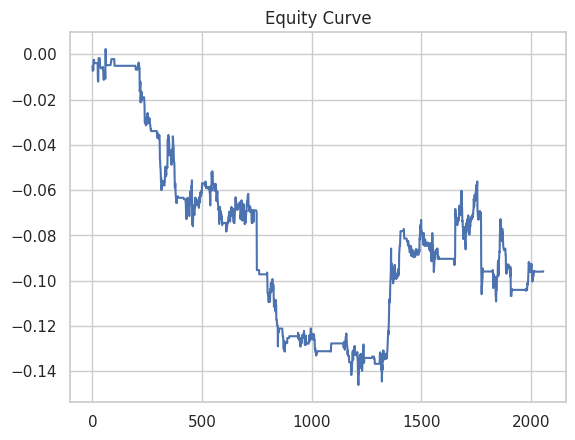

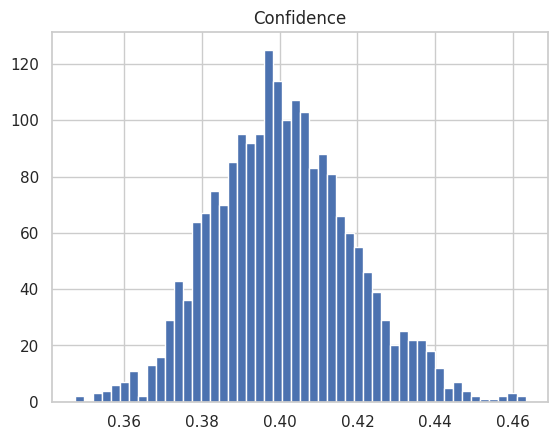


LSTM → XAUUSD_15m


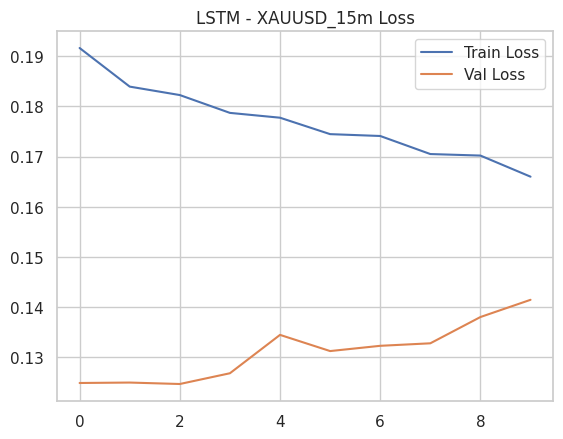

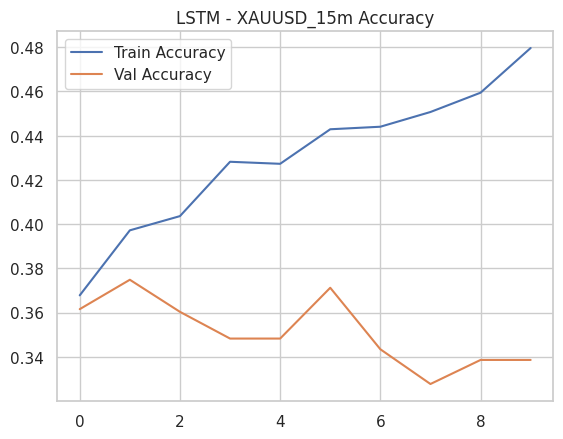

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step

Error Analysis:
Total Error Rate: 0.7016908212560387


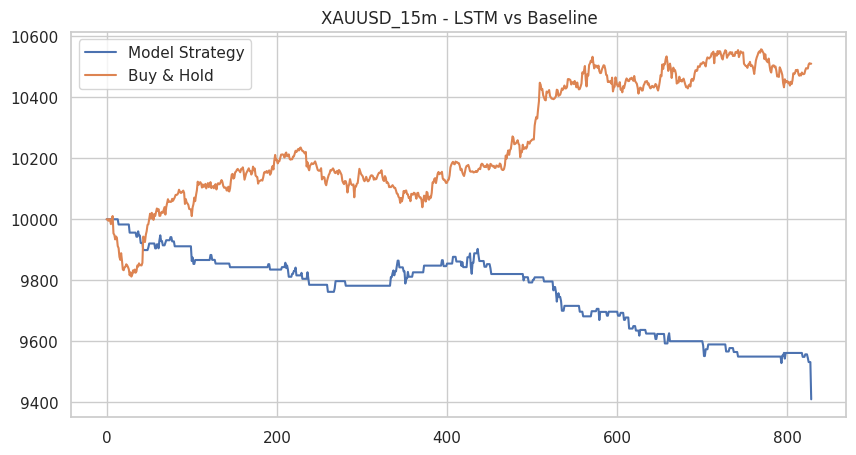

Max DD: -5.90%
Win Rate: 14.44%
Sharpe Ratio: -6.153
              precision    recall  f1-score   support

           0       0.32      0.42      0.36       270
           1       0.33      0.38      0.35       299
           2       0.16      0.08      0.10       259

    accuracy                           0.30       828
   macro avg       0.27      0.29      0.27       828
weighted avg       0.27      0.30      0.28       828

Total Errors: 581
False BUY: 234
False SELL: 103


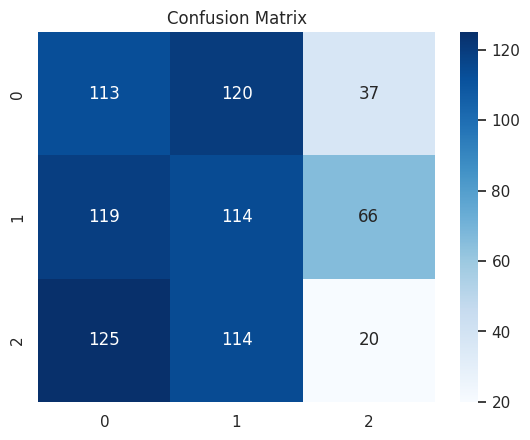

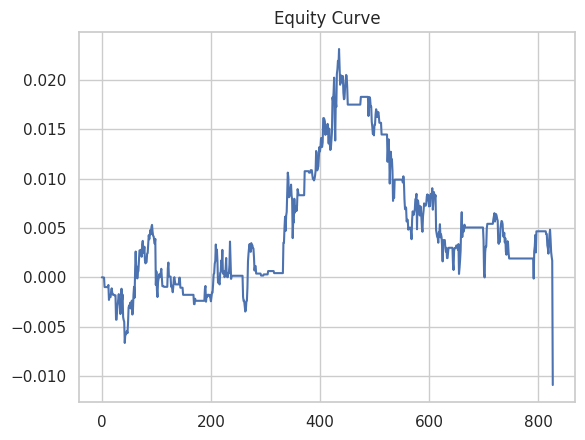

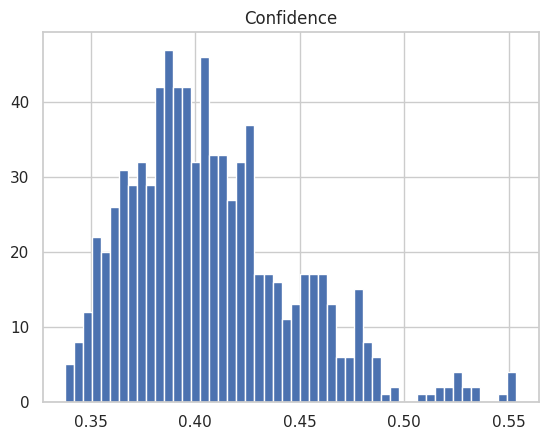


LSTM → GBPUSD_30m


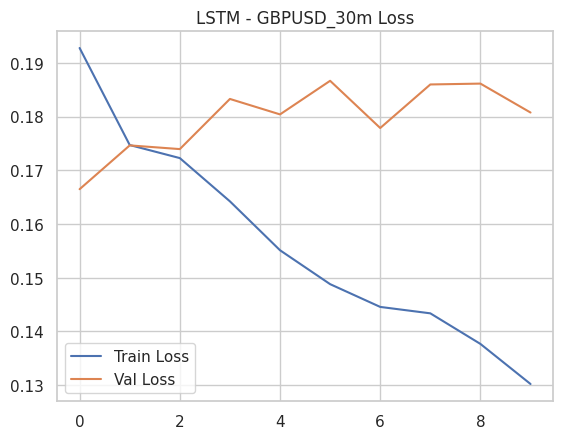

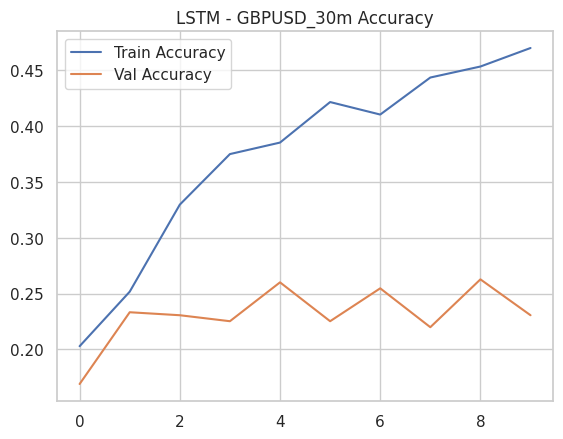

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step

Error Analysis:
Total Error Rate: 0.44235924932975873


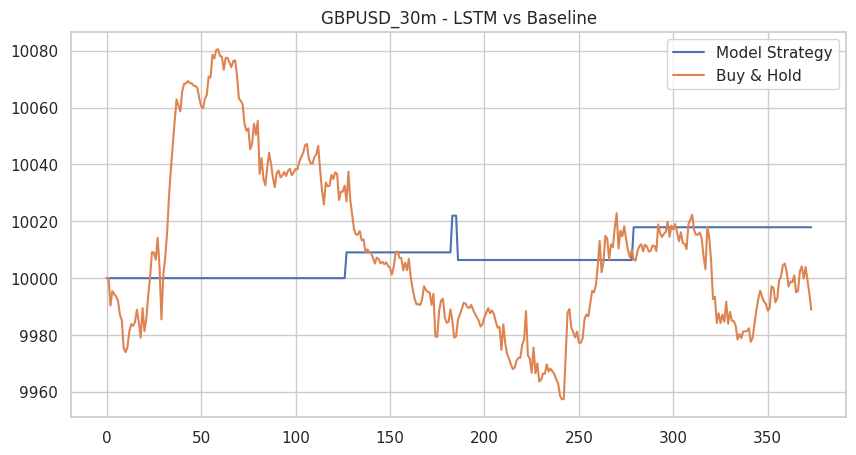

Max DD: -0.16%
Win Rate: 2.83%
Sharpe Ratio: 2.892
              precision    recall  f1-score   support

           0       0.71      0.72      0.71       263
           1       0.16      0.16      0.16        68
           2       0.21      0.19      0.20        42

    accuracy                           0.56       373
   macro avg       0.36      0.36      0.36       373
weighted avg       0.55      0.56      0.55       373

Total Errors: 165
False BUY: 56
False SELL: 31


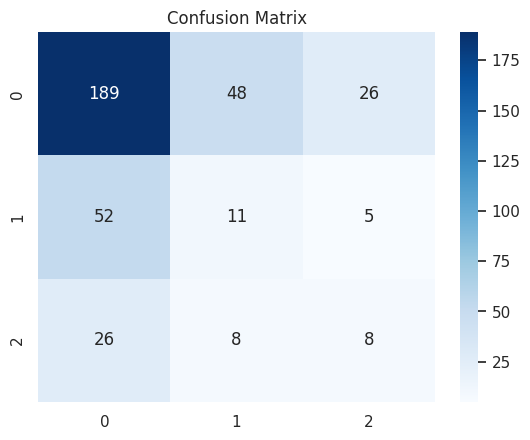

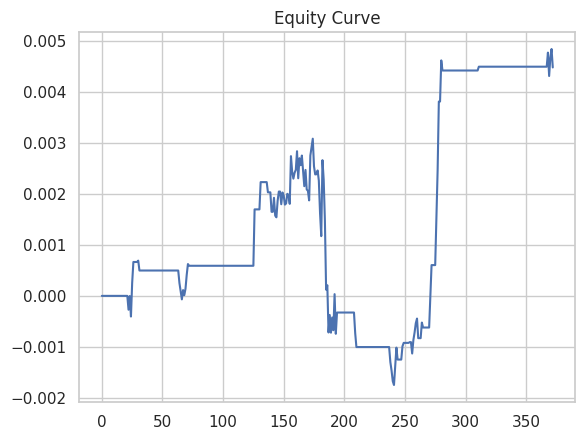

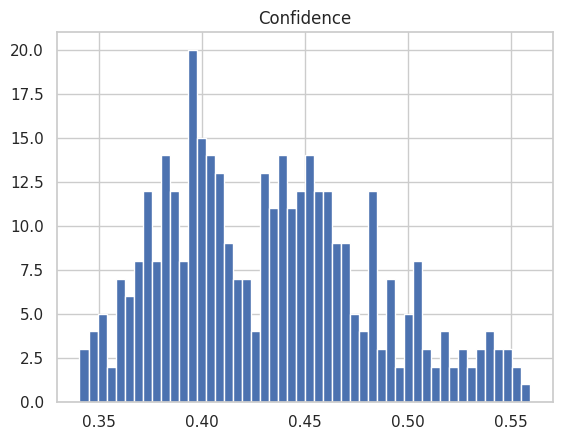

In [36]:
run_lstm(data)


MLP → IUFSUSUSD_5m


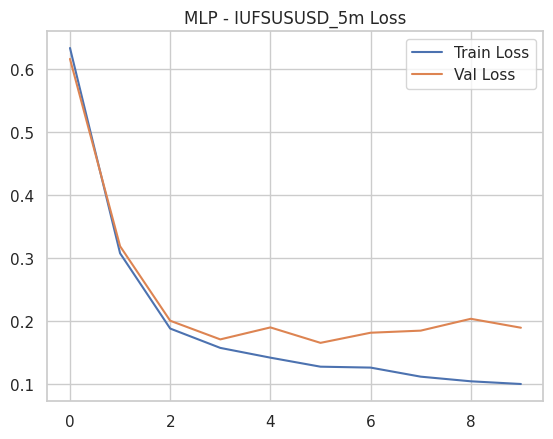

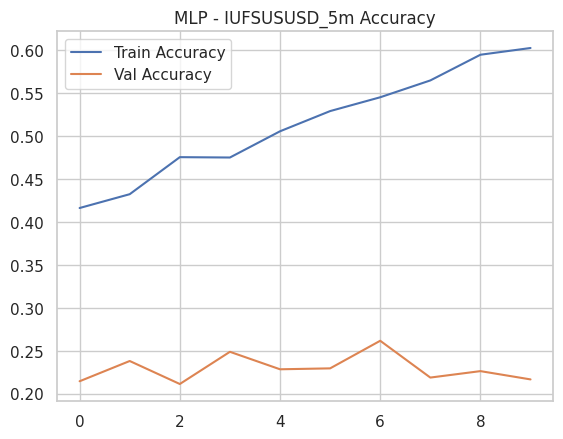

30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step

Error Analysis:
Total Error Rate: 0.5616291532690246


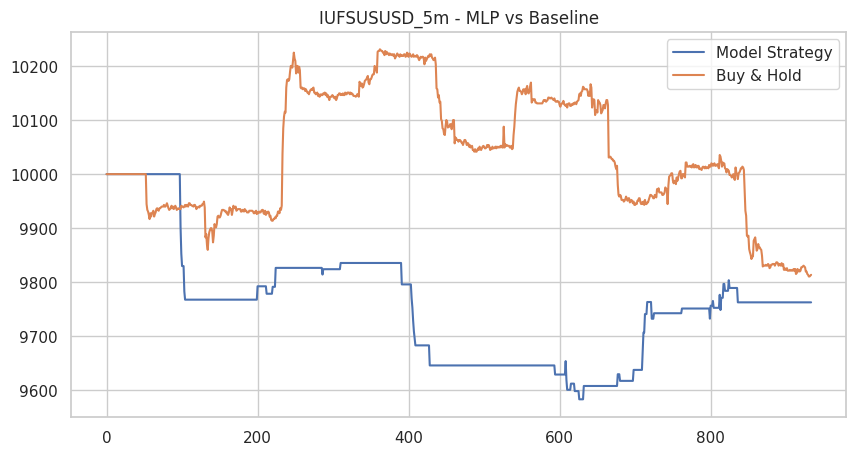

Max DD: -4.17%
Win Rate: 5.99%
Sharpe Ratio: -3.063
Total Errors: 524
False BUY: 161
False SELL: 149
              precision    recall  f1-score   support

           0       0.62      0.60      0.61       590
           1       0.14      0.16      0.15       173
           2       0.17      0.18      0.17       170

    accuracy                           0.44       933
   macro avg       0.31      0.31      0.31       933
weighted avg       0.45      0.44      0.44       933



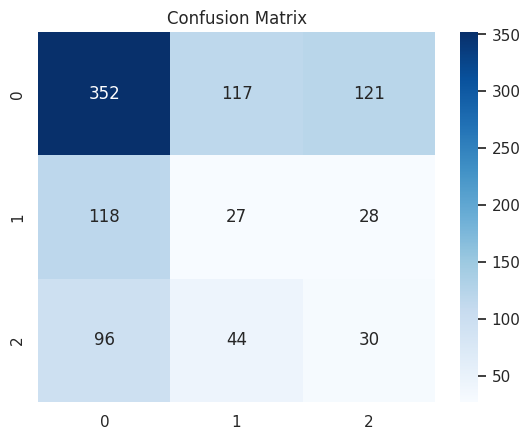

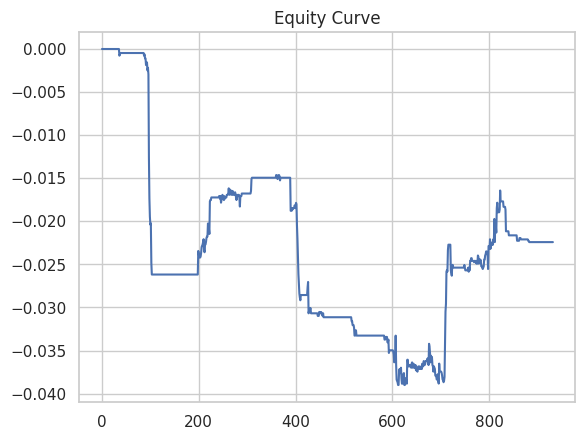

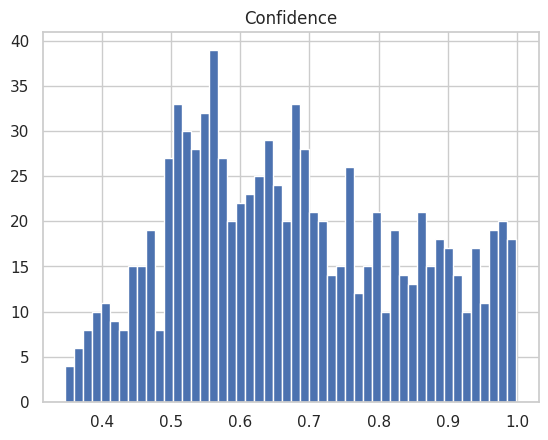


MLP → BCHUSD_10m


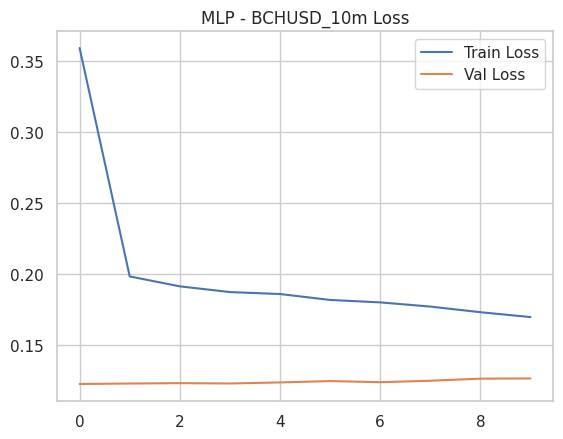

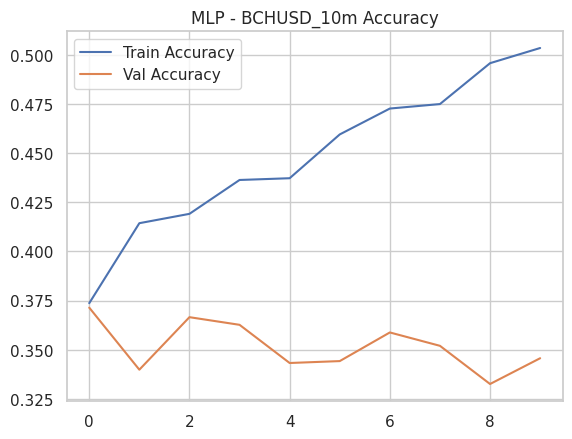

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step

Error Analysis:
Total Error Rate: 0.6358774914924648


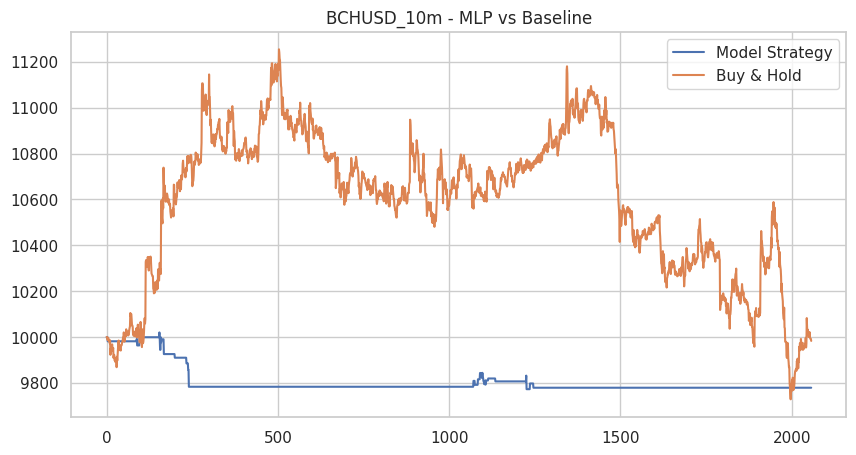

Max DD: -2.47%
Win Rate: 24.14%
Sharpe Ratio: -2.137
Total Errors: 1308
False BUY: 42
False SELL: 0
              precision    recall  f1-score   support

           0       0.37      0.97      0.53       754
           1       0.28      0.03      0.05       607
           2       0.00      0.00      0.00       696

    accuracy                           0.36      2057
   macro avg       0.21      0.33      0.19      2057
weighted avg       0.22      0.36      0.21      2057



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


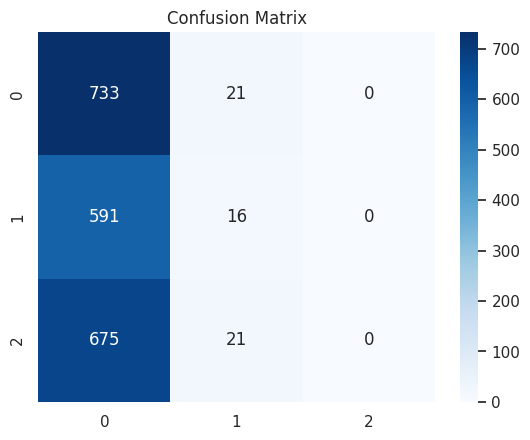

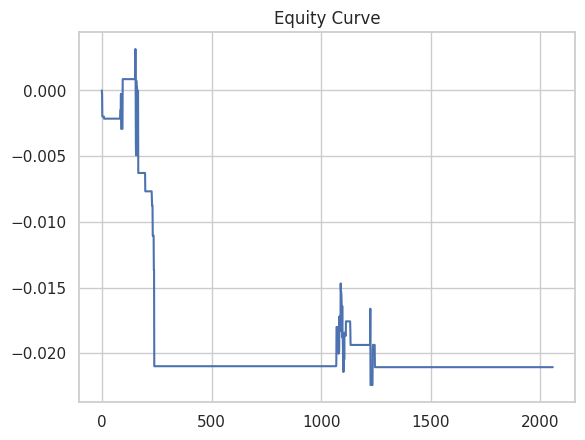

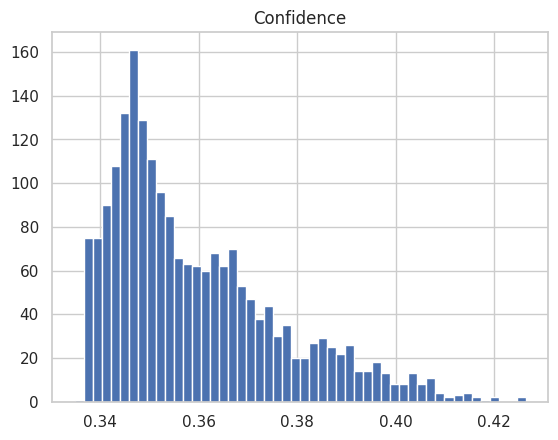


MLP → XAUUSD_15m


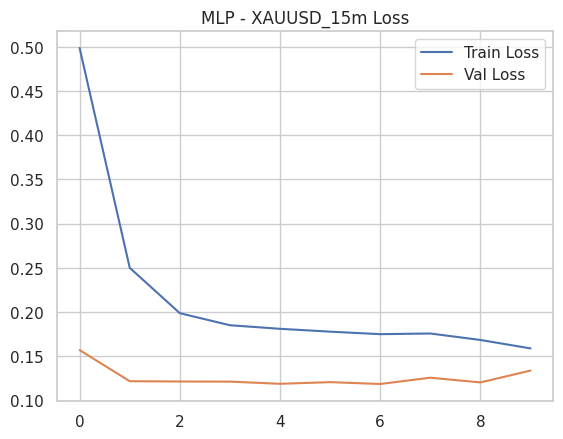

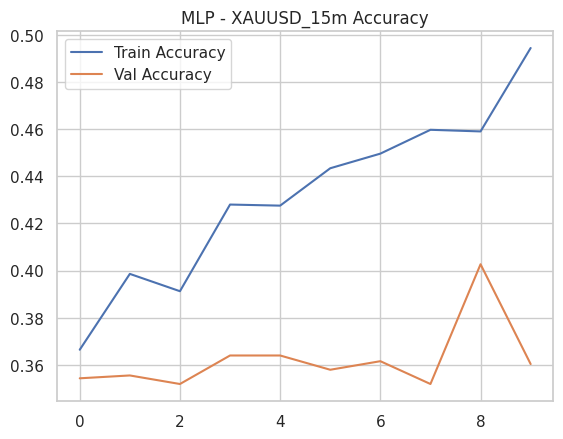

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step

Error Analysis:
Total Error Rate: 0.6739130434782609


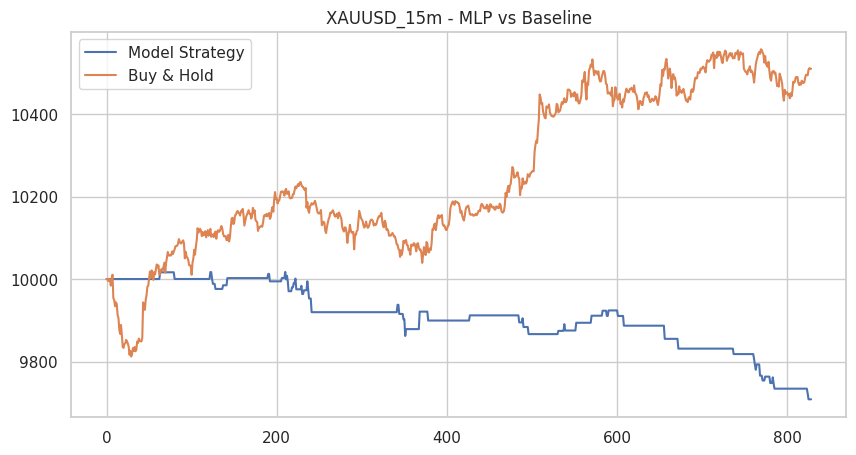

Max DD: -3.08%
Win Rate: 13.33%
Sharpe Ratio: -5.462
Total Errors: 558
False BUY: 58
False SELL: 91
              precision    recall  f1-score   support

           0       0.34      0.77      0.47       270
           1       0.34      0.10      0.16       299
           2       0.25      0.12      0.16       259

    accuracy                           0.33       828
   macro avg       0.31      0.33      0.26       828
weighted avg       0.31      0.33      0.26       828



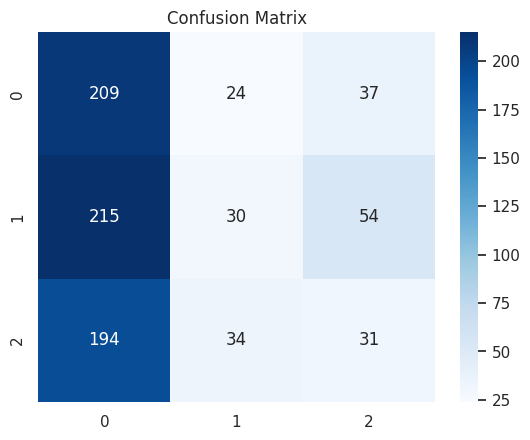

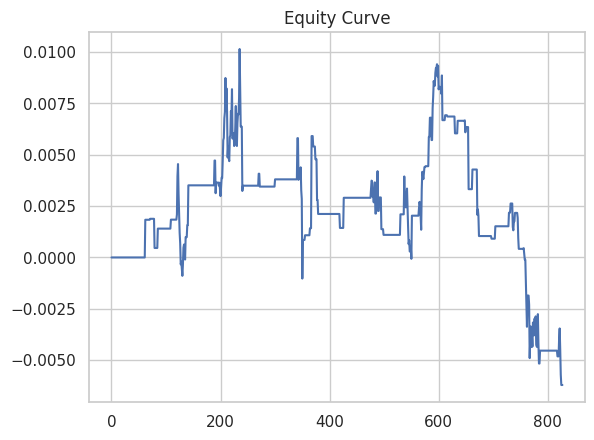

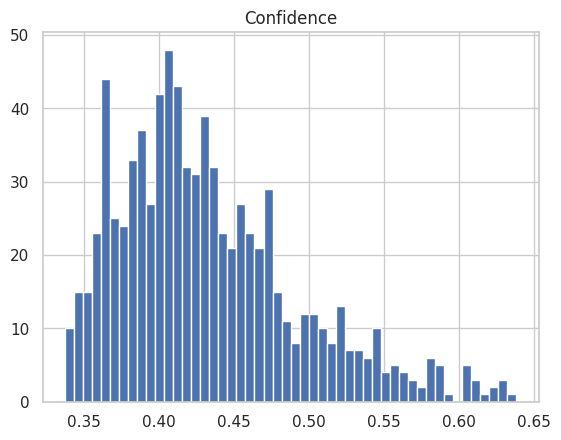


MLP → GBPUSD_30m


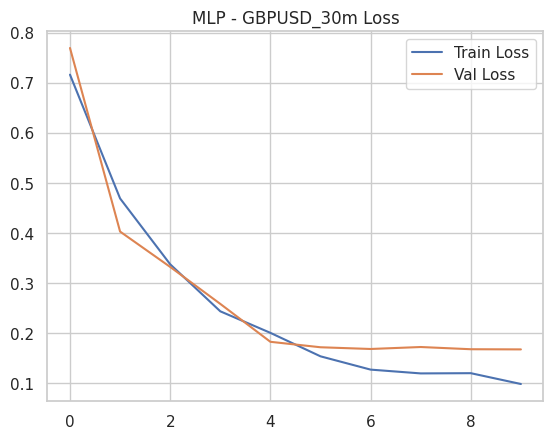

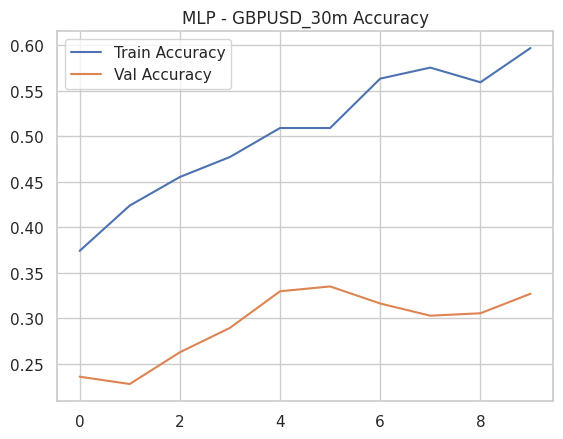

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step

Error Analysis:
Total Error Rate: 0.710455764075067


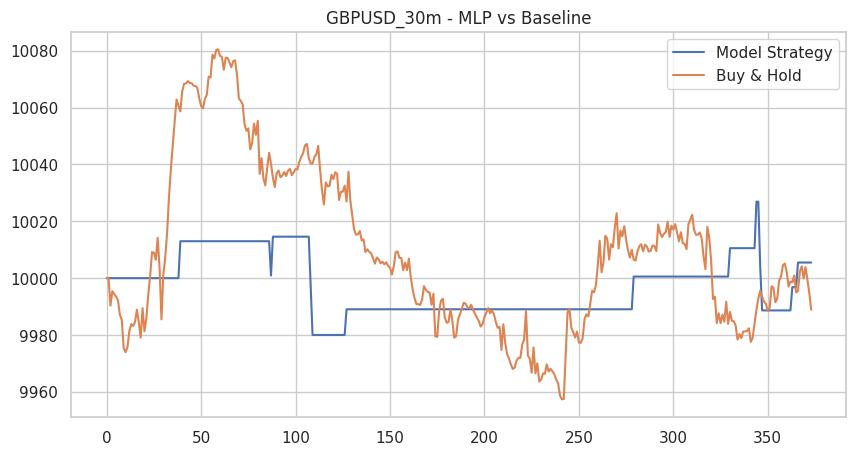

Max DD: -0.38%
Win Rate: 3.02%
Sharpe Ratio: 0.445
Total Errors: 265
False BUY: 0
False SELL: 232
              precision    recall  f1-score   support

           0       0.69      0.29      0.40       263
           1       0.00      0.00      0.00        68
           2       0.12      0.79      0.21        42

    accuracy                           0.29       373
   macro avg       0.27      0.36      0.21       373
weighted avg       0.50      0.29      0.31       373



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


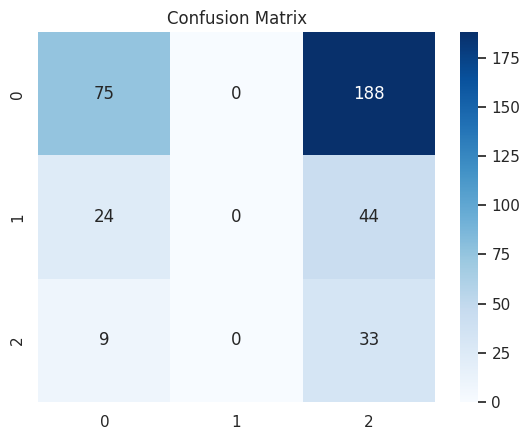

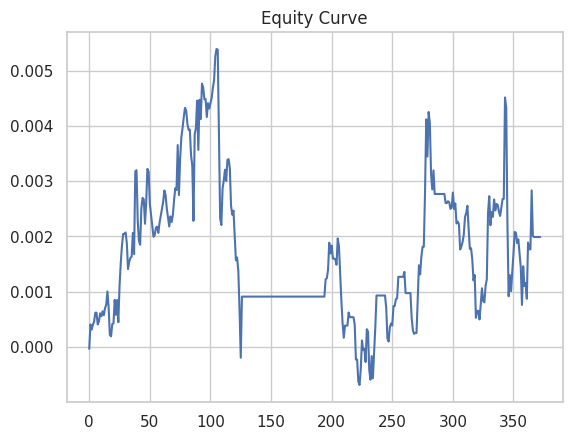

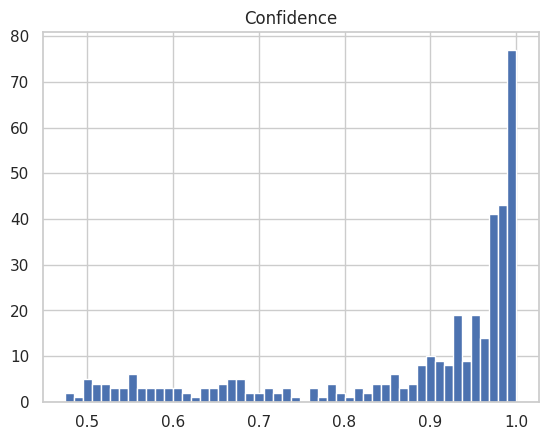

In [37]:
run_mlp(data)


RF → IUFSUSUSD_5m

Feature Importance:
body: 0.0001
range: 0.0002
upper_wick: 0.0002
lower_wick: 0.0001
body_ratio: 0.0002
direction: 0.0000
MACD: 0.0005
Signal: 0.0006
Jaw: 0.0003
Teeth: 0.0004
Lips: 0.0002
stoch_k14: 0.0004
stoch_k21: 0.0004
stoch_k28: 0.0003
volatility_10: 0.0004
volatility_20: 0.0004
volatility_50: 0.0007
atr_14: 0.0006
trend_strength: 0.0005
regime: 0.0000
hour_sin: 0.0002
hour_cos: 0.0002
dow_sin: 0.0000
dow_cos: 0.0000
is_hammer: 0.0000
is_shooting_star: 0.0000
is_doji: 0.0000
              precision    recall  f1-score   support

           0       0.73      0.60      0.66       590
           1       0.29      0.39      0.33       173
           2       0.17      0.22      0.19       170

    accuracy                           0.49       933
   macro avg       0.40      0.40      0.39       933
weighted avg       0.55      0.49      0.51       933



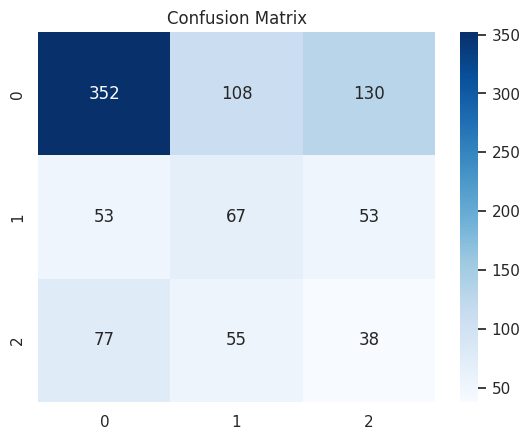


RF → BCHUSD_10m

Feature Importance:
body: 0.0003
range: 0.0003
upper_wick: 0.0003
lower_wick: 0.0003
body_ratio: 0.0005
direction: 0.0000
MACD: 0.0004
Signal: 0.0005
Jaw: 0.0005
Teeth: 0.0003
Lips: 0.0004
stoch_k14: 0.0006
stoch_k21: 0.0004
stoch_k28: 0.0004
volatility_10: 0.0004
volatility_20: 0.0005
volatility_50: 0.0005
atr_14: 0.0006
trend_strength: 0.0004
regime: 0.0000
hour_sin: 0.0001
hour_cos: 0.0002
dow_sin: 0.0001
dow_cos: 0.0000
is_hammer: 0.0000
is_shooting_star: 0.0000
is_doji: 0.0000
              precision    recall  f1-score   support

           0       0.38      0.20      0.26       754
           1       0.29      0.38      0.33       607
           2       0.33      0.42      0.37       696

    accuracy                           0.33      2057
   macro avg       0.34      0.33      0.32      2057
weighted avg       0.34      0.33      0.32      2057



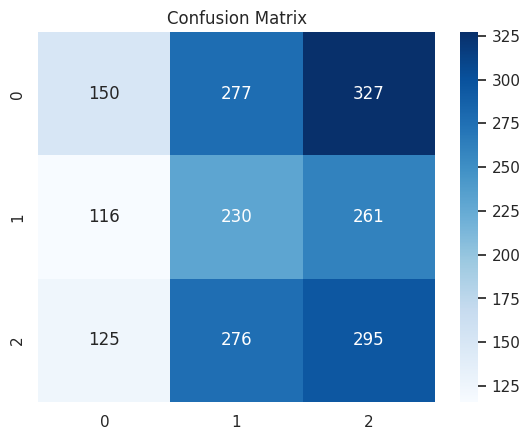


RF → XAUUSD_15m

Feature Importance:
body: 0.0002
range: 0.0003
upper_wick: 0.0003
lower_wick: 0.0003
body_ratio: 0.0003
direction: 0.0000
MACD: 0.0005
Signal: 0.0006
Jaw: 0.0004
Teeth: 0.0004
Lips: 0.0003
stoch_k14: 0.0006
stoch_k21: 0.0006
stoch_k28: 0.0004
volatility_10: 0.0006
volatility_20: 0.0005
volatility_50: 0.0005
atr_14: 0.0005
trend_strength: 0.0005
regime: 0.0000
hour_sin: 0.0001
hour_cos: 0.0001
dow_sin: 0.0000
dow_cos: 0.0001
is_hammer: 0.0000
is_shooting_star: 0.0000
is_doji: 0.0000
              precision    recall  f1-score   support

           0       0.33      0.45      0.38       270
           1       0.34      0.51      0.41       299
           2       0.33      0.01      0.02       259

    accuracy                           0.33       828
   macro avg       0.33      0.32      0.27       828
weighted avg       0.33      0.33      0.28       828



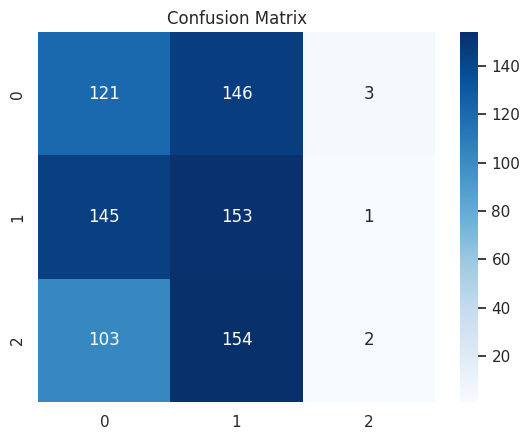


RF → GBPUSD_30m

Feature Importance:
body: 0.0001
range: 0.0003
upper_wick: 0.0003
lower_wick: 0.0001
body_ratio: 0.0002
direction: 0.0001
MACD: 0.0004
Signal: 0.0007
Jaw: 0.0003
Teeth: 0.0005
Lips: 0.0003
stoch_k14: 0.0004
stoch_k21: 0.0002
stoch_k28: 0.0002
volatility_10: 0.0003
volatility_20: 0.0005
volatility_50: 0.0002
atr_14: 0.0004
trend_strength: 0.0003
regime: 0.0000
hour_sin: 0.0002
hour_cos: 0.0002
dow_sin: 0.0003
dow_cos: 0.0001
is_hammer: 0.0000
is_shooting_star: 0.0000
is_doji: 0.0000
              precision    recall  f1-score   support

           0       0.70      0.80      0.75       263
           1       0.19      0.09      0.12        68
           2       0.00      0.00      0.00        42

    accuracy                           0.58       373
   macro avg       0.30      0.30      0.29       373
weighted avg       0.53      0.58      0.55       373



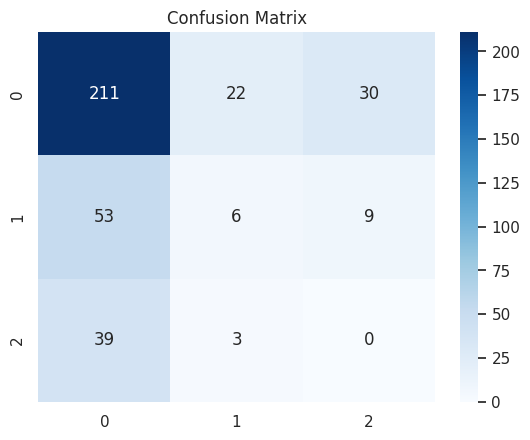

In [38]:
run_rf(data)


ENSEMBLE → IUFSUSUSD_5m
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step


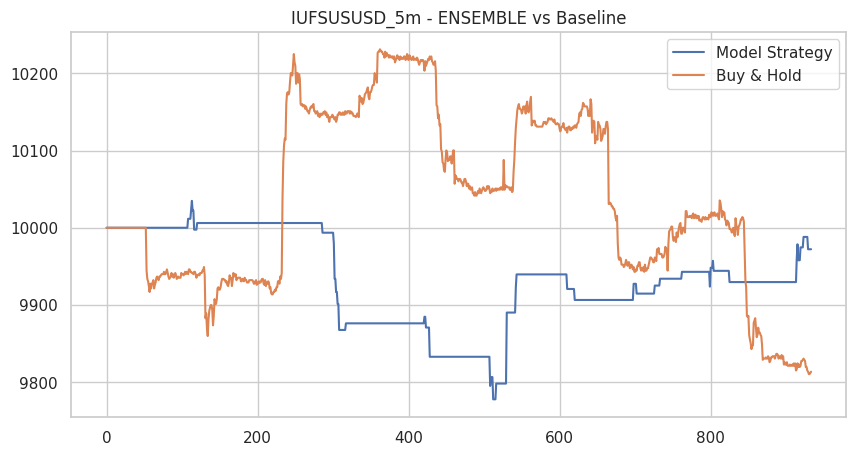


Error Analysis:
Total Error Rate: 0.5605573419078242
Max DD: -2.56%
Win Rate: 5.69%
Sharpe Ratio: -0.423
              precision    recall  f1-score   support

           0       0.62      0.59      0.60       590
           1       0.20      0.13      0.16       173
           2       0.15      0.23      0.18       170

    accuracy                           0.44       933
   macro avg       0.32      0.32      0.32       933
weighted avg       0.46      0.44      0.44       933

Total Errors: 523
False BUY: 93
False SELL: 214


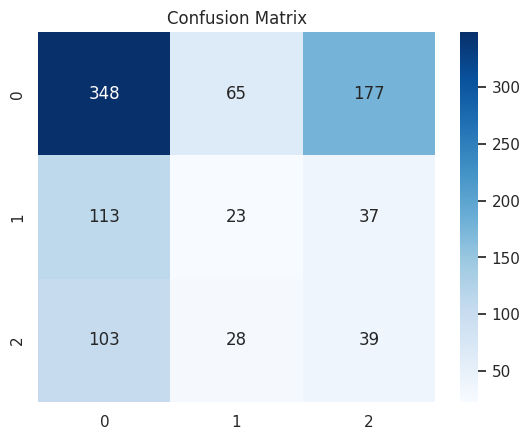

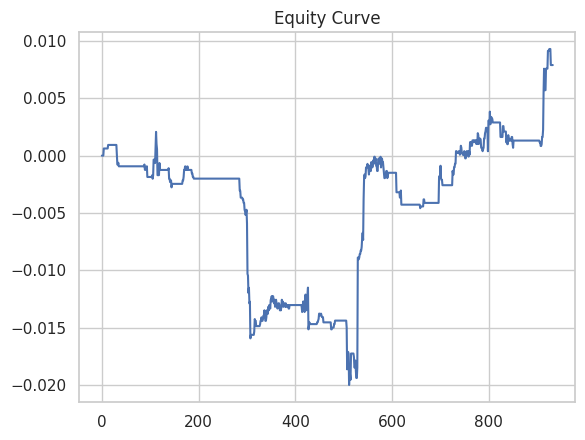

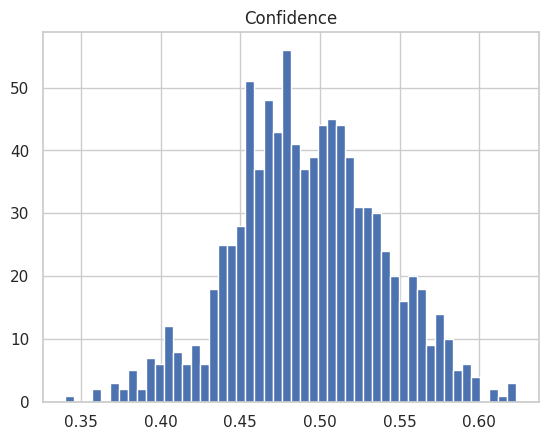

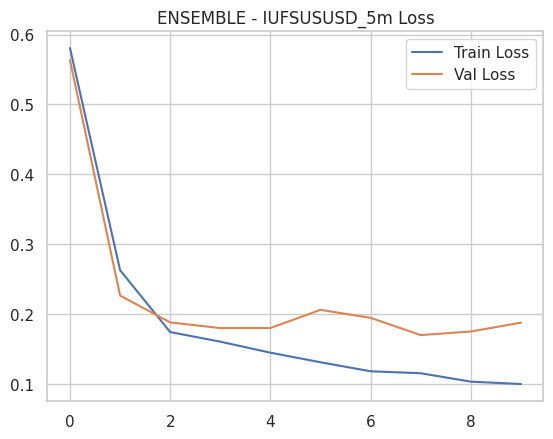

/tmp/ipykernel_876/3004085383.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


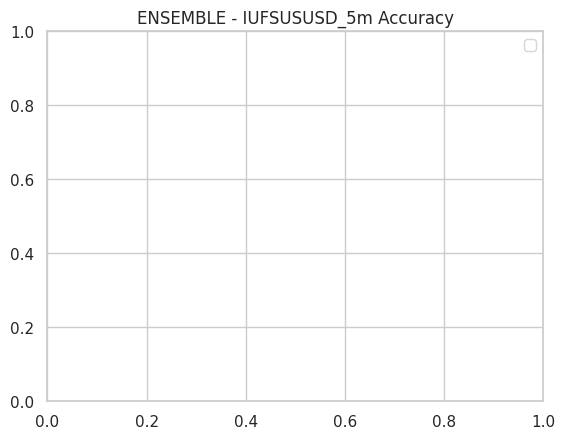


ENSEMBLE → BCHUSD_10m
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


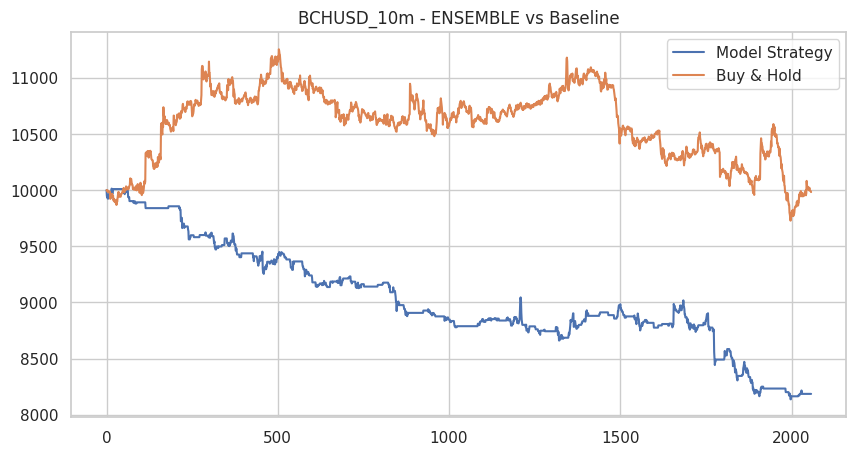


Error Analysis:
Total Error Rate: 0.6446280991735537
Max DD: -18.74%
Win Rate: 29.19%
Sharpe Ratio: -4.083
              precision    recall  f1-score   support

           0       0.37      0.56      0.44       754
           1       0.31      0.15      0.20       607
           2       0.36      0.31      0.33       696

    accuracy                           0.36      2057
   macro avg       0.34      0.34      0.33      2057
weighted avg       0.35      0.36      0.33      2057

Total Errors: 1326
False BUY: 205
False SELL: 388


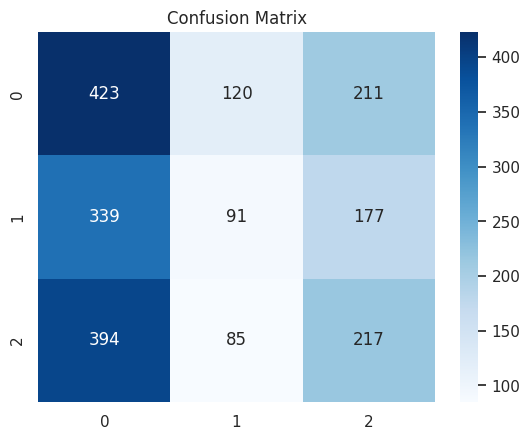

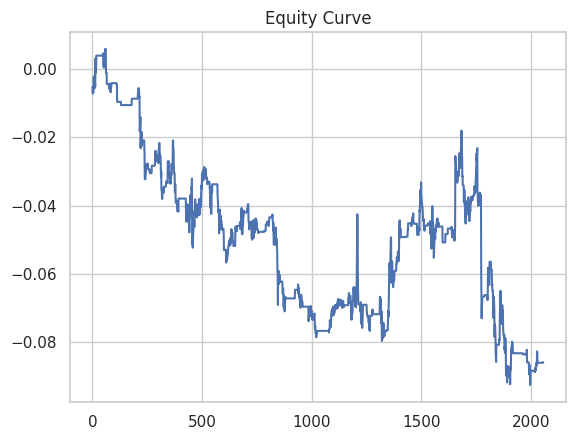

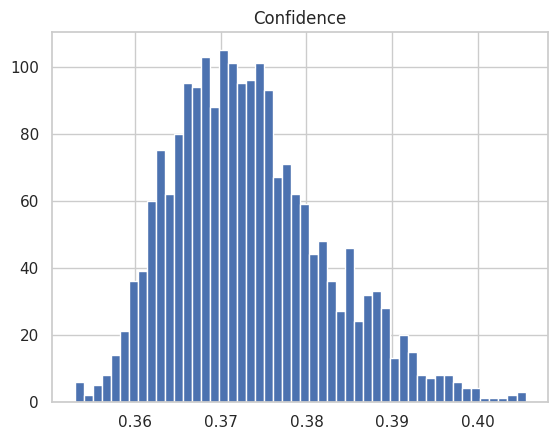

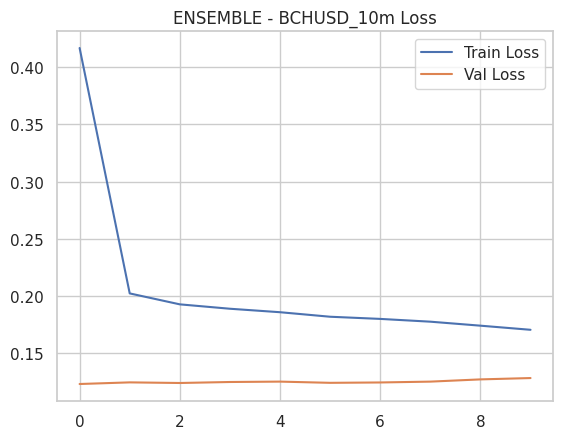

/tmp/ipykernel_876/3004085383.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


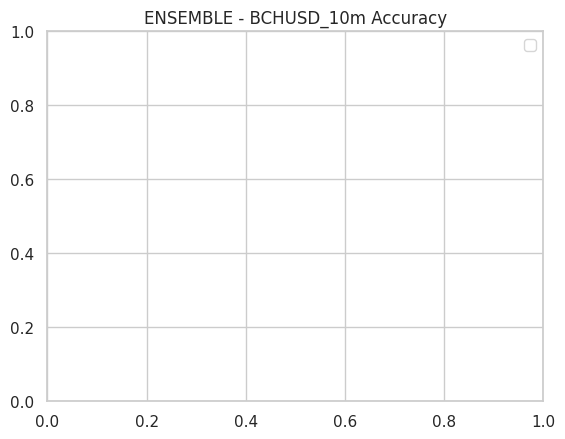


ENSEMBLE → XAUUSD_15m
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


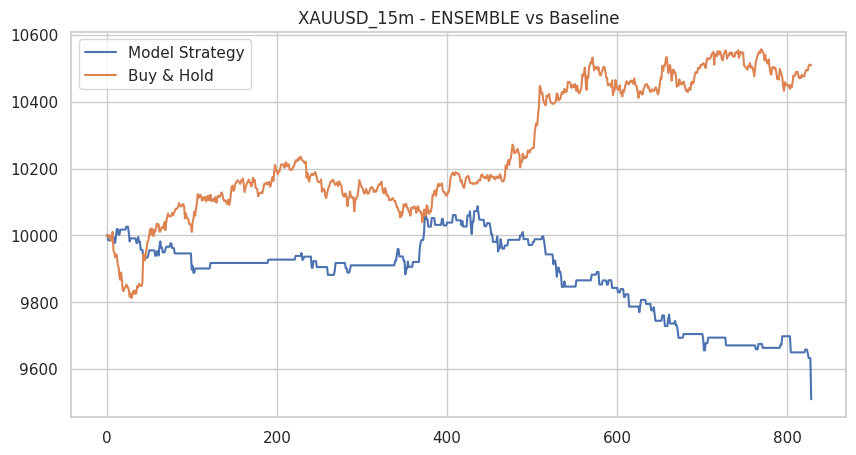


Error Analysis:
Total Error Rate: 0.6956521739130435
Max DD: -5.73%
Win Rate: 16.83%
Sharpe Ratio: -4.622
              precision    recall  f1-score   support

           0       0.30      0.36      0.33       270
           1       0.33      0.42      0.37       299
           2       0.25      0.11      0.15       259

    accuracy                           0.30       828
   macro avg       0.29      0.30      0.28       828
weighted avg       0.29      0.30      0.29       828

Total Errors: 576
False BUY: 257
False SELL: 88


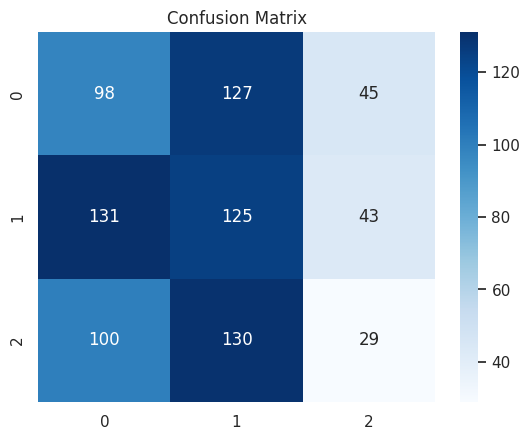

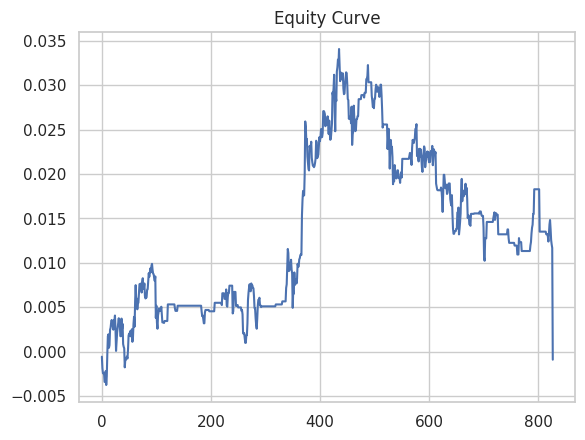

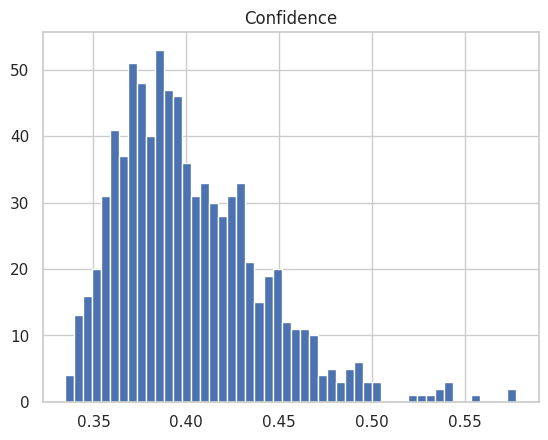

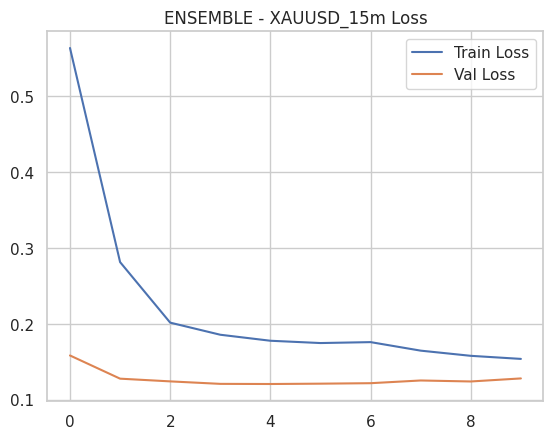

/tmp/ipykernel_876/3004085383.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


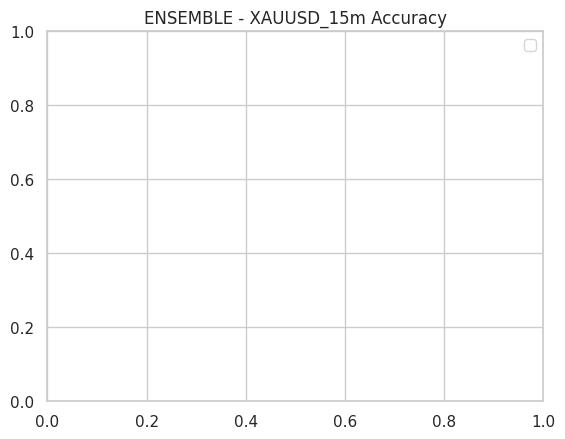


ENSEMBLE → GBPUSD_30m
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


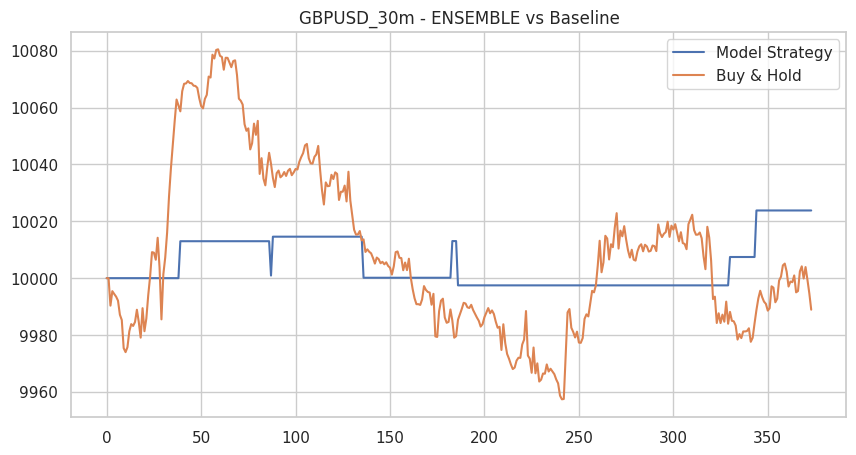


Error Analysis:
Total Error Rate: 0.6300268096514745
Max DD: -0.17%
Win Rate: 2.63%
Sharpe Ratio: 2.494
              precision    recall  f1-score   support

           0       0.63      0.44      0.52       263
           1       0.16      0.18      0.17        68
           2       0.09      0.26      0.14        42

    accuracy                           0.37       373
   macro avg       0.30      0.29      0.27       373
weighted avg       0.48      0.37      0.41       373

Total Errors: 235
False BUY: 62
False SELL: 105


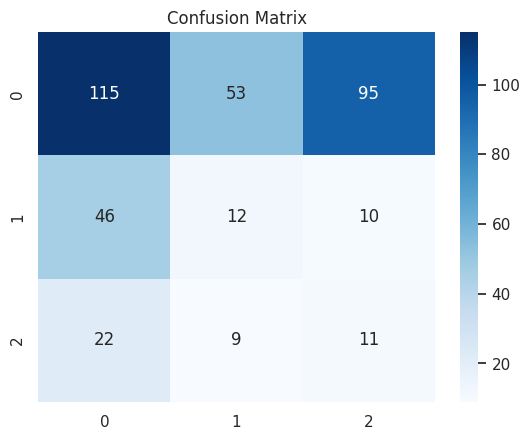

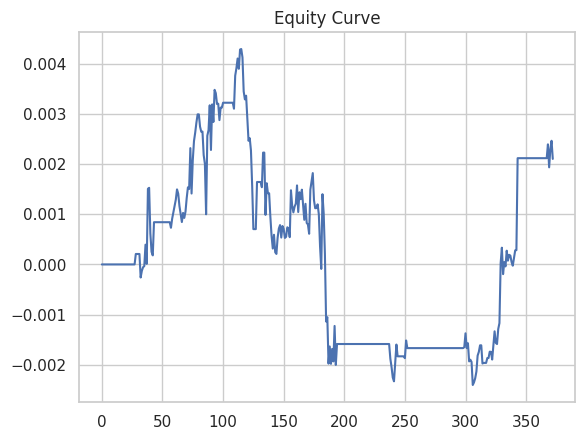

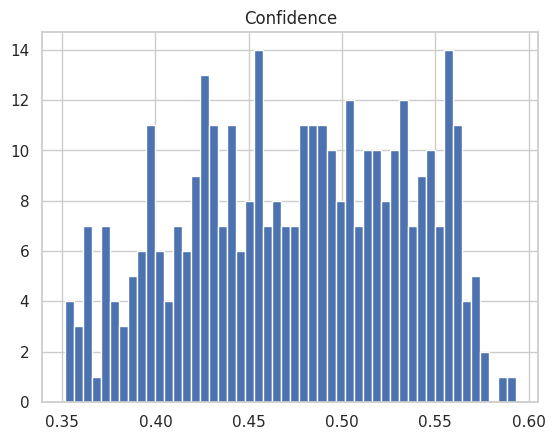

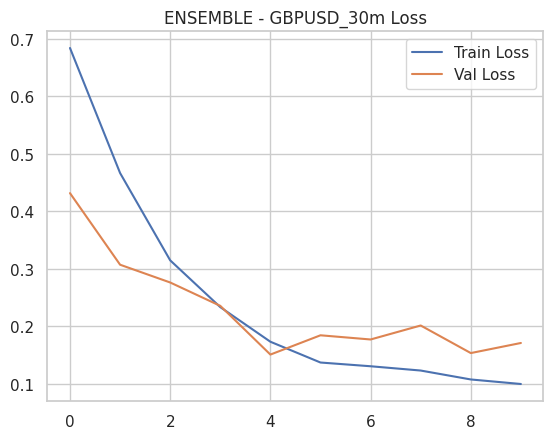

/tmp/ipykernel_876/3004085383.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


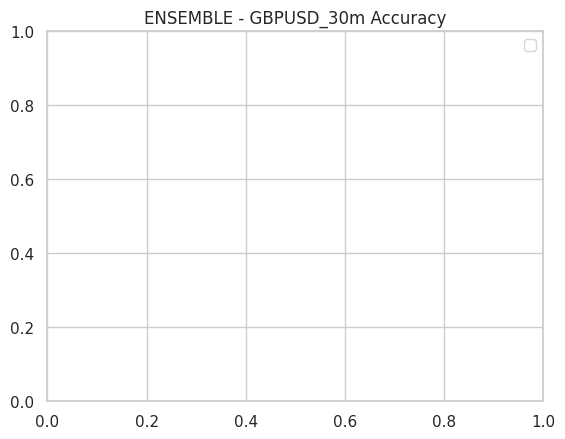

In [39]:
run_ensemble(data)

In [40]:
# ===============================
# WALK-FORWARD VALIDATION
# ===============================
for name, (df, *_ ) in data.items():
    walk_forward_proper(build_cnn, df, name)


WALK-FORWARD → IUFSUSUSD_5m
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step

Walk-forward results for IUFSUSUSD_5m
Mean Sharpe: 0.0
Std Sharpe: 0.0
Min Sharpe: 0
Max Sharpe: 0

WALK-FORWARD → BCHUSD_10m
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

Walk-forward results for BCHUSD_10m
Mean Sharpe: 0.0
Std Sharpe: 0.0
Min Sharpe: 0
Max Sharpe: 0

WALK-FORWARD → XAUUSD_15m
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

Walk-forward results for XAUUSD_15m
Mean Sharpe: 0.0
Std Sharpe: 0.0
Min Sharpe: 0
Max Sharpe: 0

WALK-FORWARD → GBPUSD_30m
No valid walk-forward windows


In [41]:
results_df = show_results_table()


===== FINAL RESULTS TABLE =====
         Model    Instrument    Sharpe  Max Drawdown  Win Rate
14        LSTM    GBPUSD_30m  2.892266     -0.001556  0.028302
30    ENSEMBLE    GBPUSD_30m  2.493681     -0.001710  0.026316
8         LSTM  IUFSUSUSD_5m  0.641507     -0.021115  0.065041
22         MLP    GBPUSD_30m  0.445487     -0.003815  0.030189
21  Buy & Hold    XAUUSD_15m  0.441985           NaN       NaN
29  Buy & Hold    XAUUSD_15m  0.441985           NaN       NaN
5   Buy & Hold    XAUUSD_15m  0.441985           NaN       NaN
13  Buy & Hold    XAUUSD_15m  0.441985           NaN       NaN
15  Buy & Hold    GBPUSD_30m -0.066276           NaN       NaN
7   Buy & Hold    GBPUSD_30m -0.066276           NaN       NaN
31  Buy & Hold    GBPUSD_30m -0.066276           NaN       NaN
23  Buy & Hold    GBPUSD_30m -0.066276           NaN       NaN
24    ENSEMBLE  IUFSUSUSD_5m -0.422526     -0.025632  0.056911
19  Buy & Hold    BCHUSD_10m -0.509364           NaN       NaN
3   Buy & Hold    BCHU

In [42]:
run_ablation(data)


===== ABLATION STUDY =====

IUFSUSUSD_5m
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step
ALL: 0.5831
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
NO_CANDLE: 0.5831
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
ONLY_TECH: 0.5831
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
ONLY_PRICE: 0.5831

BCHUSD_10m
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
ALL: 0.3368
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
NO_CANDLE: 0.3337
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
ONLY_TECH: 0.3337
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
ONLY_PRICE: 0.3337

XAUUSD_15m
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
ALL: 0.3400
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
NO_CANDLE: 0.3312
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
ONLY_TECH: 0.3145
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
ONLY_PRICE: 0.3718

GBPUSD_30m
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
ALL: 0.6749
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
NO_CANDLE: 0.6749
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
ONLY_TECH: 0.6749
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
ONLY_PRICE: 0.6749


In [43]:
tune_cnn(data)


===== HYPERPARAMETER TUNING =====

IUFSUSUSD_5m | lr=0.001, batch=32
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Sharpe: -1.604

IUFSUSUSD_5m | lr=0.001, batch=64
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Sharpe: 0.000

IUFSUSUSD_5m | lr=0.0005, batch=32
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Sharpe: 0.399

IUFSUSUSD_5m | lr=0.0005, batch=64
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Sharpe: 0.000

BCHUSD_10m | lr=0.001, batch=32
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Sharpe: 0.066

BCHUSD_10m | lr=0.001, batch=64
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Sharpe: 0.066

BCHUSD_10m | lr=0.0005, batch=32
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Sharpe: 0.182

BCHUSD_10m | lr=0.0005, batch=64
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Sharpe: 0.107

XAUUSD_15m | lr=0.001, batch=32
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Sharpe: 0.000

XAUUSD_15m | lr=0.001, batch=64
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Sharpe: 4.488

XAUUSD_15m | lr=0.0005, batch=32
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Sharpe: 